# Análisis de datos de abolladuras

## 📋 Notas sobre el dataset

**Archivo utilizado:** `todos_los_resultados_csv_remapeado_final.csv`

---

### 🔄 Sistema de Remapeo

Este análisis utiliza el dataset con **remapeo completo de detecciones parciales** para:
- **Beams** (vigas)
- **Inclined_legs** (piernas inclinadas)

---

### 📊 Valores en `DeteccionOK`

La columna `DeteccionOK` contiene valores numéricos que representan diferentes tipos de detección:

| Valor | Significado | Descripción |
|-------|-------------|-------------|
| **0** | ❌ No detectado | El AG no encontró daño (ni directa ni indirectamente) |
| **0.5** | ⚠️ Detección parcial | Daño detectado en **nodos cercanos** al elemento |
| **1** | ✅ Detectado directamente | El AG detectó el daño en el elemento específico |

---

### 📐 Uso en diferentes análisis

**Para análisis de tasas de detección** (Figuras 1 y 2):
- Se considera **detección exitosa** cuando `DeteccionOK > 0`
- Valores **0.5** y **1** se tratan como éxito (binario)

**Para el Índice de Calidad de Detección (ICD)**:
- Se utiliza el **valor directo** (0, 0.5, o 1)
- Las detecciones parciales aportan **0.5 puntos** al índice
- Permite cuantificar la calidad de la detección con mayor precisión

---

## Figura 1 — Tasa de detección vs % de daño

**Objetivo.** Visualizar el desempeño del AG conforme aumenta la severidad de abolladura. La gráfica muestra, para cada nivel de **Porcentaje** (5–45%), la **tasa de detección**:
\[
\text{TasaDetección}(d)=\frac{\#\{\text{corridas con DeteccionOK}=1 \ \&\ \%\text{daño}=d\}}{\#\{\text{corridas con }\%\text{daño}=d\}}
\]

**Qué ver.**
- Puntos (o barras) por nivel de daño con su **IC 95%** (binomial, p. ej. Wilson).
- Tendencia creciente: a mayor daño, **mayor probabilidad de detección (POD)**.

**Cómo leerla.**
- La altura en cada **%** es la fracción de corridas en las que el AG localizó correctamente el elemento dañado.
- Si dos niveles tienen ICs que **no se solapan**, hay evidencia de mejora real en detección.
- Útil para estimar un **umbral operativo** mínimo de daño donde la detección ya es “fiable” (p. ej., ≥0.8).

**Relación con POD/MDD.**
- Esta figura es el insumo empírico de la curva **POD(d)**.
- A partir del ajuste logístico \(\text{POD}(d)=\sigma(a+bd)\), más adelante se reportan:
  - **MDD50**: daño con \(\text{POD}=0.50\)
  - **MDD90**: daño con \(\text{POD}=0.90\)

**Notas.**
- Convertir `DeteccionOK` a 0/1 antes de agregar.
- Reportar el **n** por cada % de daño; si es desigual, interpretar ICs con cautela.
- (Opcional) Estratificar por `Tipo_elemento_a_buscar` para comparar piernas vs diagonales/vigas.

**Mensaje clave.**
> Esta figura responde: *“¿Con qué frecuencia el AG acierta y cómo mejora esa frecuencia cuando el daño es mayor?”*; sienta la base para cuantificar el **Mínimo Daño Detectable (MDD)**.


In [76]:
# --- Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
# ============================================
# PARÁMETROS GLOBALES PARA EL CÁLCULO DEL ICD
# ============================================
# Estos parámetros se usan consistentemente en todo el análisis

# Factor de Confianza (severidad logarítmica normalizada)
ALPHA = 0.1  # Parámetro de ajuste para el escalado logarítmico
PORCENTAJE_MAX = 90.0  # Porcentaje máximo de daño en el dataset (corrosión)

# Factor de Penalización de Falsos Positivos (decaimiento exponencial)
BETA = 0.15 # Penalización gradual: 1 FP ≈ -14%, 5 FP ≈ -53%, 10 FP ≈ -78%
# BETA = 0.30 # Penalización moderada: 1 FP ≈ -26%, 5 FP ≈ -78%, 10 FP ≈ -95%
# BETA = 1.00 # Penalización severa: 1 FP ≈ -63%, 5 FP ≈ -99%, 10 FP ≈ -100%

# Constante de normalización (calculada automáticamente)
import numpy as np
C_MAX = np.log(1 + ALPHA * PORCENTAJE_MAX)  # Para α=0.1, %max=90

print(f"✅ Parámetros ICD configurados:")
print(f"   ALPHA = {ALPHA} (escalado logarítmico)")
print(f"   BETA = {BETA} (penalización de FP)")
print(f"   PORCENTAJE_MAX = {PORCENTAJE_MAX}%")
print(f"   C_MAX = {C_MAX:.4f} (normalización)")

✅ Parámetros ICD configurados:
   ALPHA = 0.1 (escalado logarítmico)
   BETA = 0.15 (penalización de FP)
   PORCENTAJE_MAX = 90.0%
   C_MAX = 2.3026 (normalización)


,Percentage,n,hits,rate,lo,hi
0,5,120,116,0.966667,0.917420,0.986962
1,10,120,116,0.966667,0.917420,0.986962
2,15,120,116,0.966667,0.917420,0.986962
3,20,120,116,0.966667,0.917420,0.986962
4,25,120,116,0.966667,0.917420,0.986962
5,30,120,116,0.966667,0.917420,0.986962
6,35,120,116,0.966667,0.917420,0.986962
7,40,120,116,0.966667,0.917420,0.986962
8,45,120,116,0.966667,0.917420,0.986962
9,50,120,115,0.958333,0.906159,0.982073


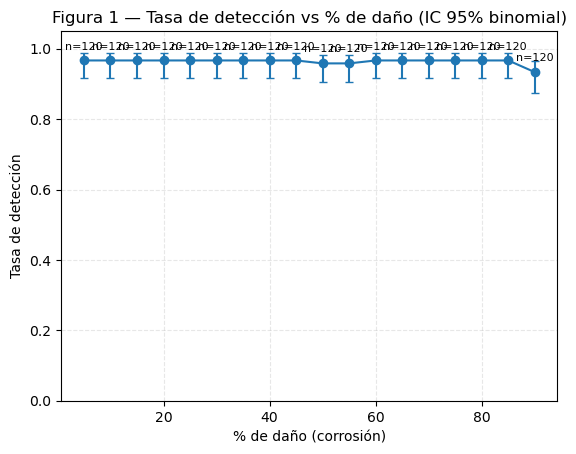

In [78]:
# ============================================
# Figura 1 — Tasa de detección vs % de daño
# (con IC binomial 95% tipo Wilson)
# ============================================

# --- Ruta del CSV (ajústala si es necesario)
CSV_PATH = "todos_los_resultados_csv_remapeado_final.csv"  # Archivo con remapeo completo (beams + inclined_legs)

# --- Cargar datos
df = pd.read_csv(CSV_PATH)

# --- Preprocesamiento
# A) % de daño a numérico
df["Percentage"] = pd.to_numeric(df["Percentage"], errors="coerce")

# B) Convertir DetectionOK a numérico (ahora ya viene como 0, 0.5, o 1)
# Para análisis de tasa de detección binaria, consideramos 1 como detección exitosa
df["DetOK_bin"] = pd.to_numeric(df["DetectionOK"], errors="coerce")
df = df.dropna(subset=["Percentage", "DetOK_bin"])

# Para este análisis de tasa de detección, convertimos 0.5 y 1 a "detección exitosa" (1)
# y solo 0 como "no detección" (0)
# Si quieres tratar 0.5 como detección parcial en el ICD, usa df["DetectionOK"] directamente
df["DetOK_bin"] = (df["DetOK_bin"] > 0).astype(int)

# --- Función: intervalo de Wilson (IC 95% por defecto)
def wilson_ci(hits: int, n: int, conf: float = 0.95):
    if n == 0:
        return (np.nan, np.nan)
    # z para el nivel de confianza (aprox. 1.96 para 95%)
    z = 1.959963984540054 if abs(conf - 0.95) < 1e-9 else {
        0.90: 1.6448536269514722,
        0.95: 1.959963984540054,
        0.99: 2.5758293035489004
    }.get(conf, 1.959963984540054)
    p = hits / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2.0 * n)) / denom
    half = (z / denom) * math.sqrt((p * (1.0 - p) / n) + (z**2) / (4.0 * n**2))
    return (center - half, center + half)

# --- Agregación por % de daño
res = (
    df.groupby("Percentage", as_index=False)
      .agg(n=("DetOK_bin", "size"), hits=("DetOK_bin", "sum"))
      .sort_values("Percentage")
)
res["rate"] = res["hits"] / res["n"]
cis = res.apply(lambda r: pd.Series(wilson_ci(int(r["hits"]), int(r["n"]), conf=0.95), index=["lo", "hi"]), axis=1)
res = pd.concat([res, cis], axis=1)

# --- (Opcional) Vista rápida de la tabla agregada
try:
    from IPython.display import display
    display(res[["Percentage", "n", "hits", "rate", "lo", "hi"]])
except Exception:
    print(res[["Percentage", "n", "hits", "rate", "lo", "hi"]])

# --- Gráfica con barras de error (IC 95%)
x = res["Percentage"].to_numpy()
y = res["rate"].to_numpy()
yerr = np.vstack([y - res["lo"].to_numpy(), res["hi"].to_numpy() - y])

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=3)
plt.title("Figura 1 — Tasa de detección vs % de daño (IC 95% binomial)")
plt.xlabel("% de daño (corrosión)")
plt.ylabel("Tasa de detección")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)

# Anotar n sobre cada punto (pequeño)
for xi, yi, ni in zip(x, y, res["n"].astype(int).to_numpy()):
    plt.annotate(f"n={ni}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.show()

# --- (Opcional) Guardar tabla de resultados
# res.to_csv("resumen_tasa_deteccion_por_porcentaje.csv", index=False)

# IC 95% Binomial — Interpretación en la Figura 1

### 🔹 Qué significa
El **IC 95% binomial** (Intervalo de Confianza del 95 % para una proporción binomial) es un estándar estadístico que muestra **cuánta incertidumbre hay en una tasa de detección** calculada a partir de resultados binarios (detección ✅ o no detección ❌).

En esta figura:
- Cada punto azul representa la **tasa de detección promedio** calculada a partir de **120 simulaciones independientes** para cada nivel de daño.
- Las barras verticales representan el **intervalo de confianza al 95 %** de esa proporción binomial, es decir, el rango en el que se espera que esté el valor real de la tasa de detección con 95 % de confianza.

---

### 🔹 Por qué se llama “binomial”
Cada ejecución del algoritmo tiene solo dos resultados posibles:
\[
\text{DetecciónOK} =
\begin{cases}
1 & \text{si detecta correctamente el daño} \\
0 & \text{si no lo detecta}
\end{cases}
\]
Al repetirse 120 veces, el número de éxitos sigue una **distribución binomial** \( B(n=120, p) \), donde \( p \) es la probabilidad real de detección.

---

### 🔹 Cómo se calcula
Una estimación común del intervalo de confianza usa el método de **Wilson** (recomendado para ingeniería y POD):

\[
\text{IC}_{95\%} = p \pm 1.96 \sqrt{\frac{p(1-p)}{n}}
\]

Donde:
- \( p \) es la tasa observada (por ejemplo, 0.67),
- \( n = 120 \) es el número de corridas o muestras,
- 1.96 corresponde al 95 % de confianza en una distribución normal.

---

### 🔹 Interpretación práctica
- Las barras verticales indican la **variabilidad esperada** si se repitiera el experimento.  
- **Barras cortas** → alta consistencia entre corridas (mayor confianza).  
- **Barras largas** → resultados más variables (menor confianza).  
- Si los intervalos de dos puntos **se solapan**, no se puede afirmar que exista una diferencia estadísticamente significativa entre ellos.

---

### 🔹 Por qué se usa
En ingeniería estructural, ensayos no destructivos y detección de daños, el **IC 95% binomial** es un **estándar internacional** (referencias típicas: *MIL-HDBK-1823A*, *ASTM E2862*, *DNVGL-RP-A203*) para representar la **incertidumbre de la Probabilidad de Detección (POD)**.  
Permite mostrar gráficamente tanto:
- la **tendencia central** (la tasa media),  
- como la **confianza estadística** en esa estimación.

---

### 🔹 En tu gráfico
Con \( n = 120 \):
- Los **intervalos son estrechos**, lo que indica **alta estabilidad estadística**.  
- La tasa de detección se mantiene **casi constante (~0.67)**, y el IC 95% refleja que, aunque hay fluctuaciones menores, **no hay diferencias estadísticamente significativas** entre los distintos porcentajes de daño.

---

✅ **En resumen:**
> El “IC 95% binomial” es una medida estándar de **incertidumbre estadística** aplicada a tasas de detección calculadas sobre \( n = 120 \) ensayos binarios.  
> En tu caso, muestra que el modelo tiene **una tasa de detección estable y confiable**, con una **alta precisión estadística** g


## Hallazgos — Figura 1: Tasa de detección vs % de daño (IC 95%)

- **Tasa global (n=1080):** 0.678  
  *IC95%:* 0.649–0.705.

- **Por severidad (n=120 por nivel):**
  - **5%:** 0.633 (76/120) — *IC95%:* 0.544–0.714.
  - **10%–45% (cada nivel):** 0.683 (82/120) — *IC95% por nivel:* 0.596–0.760.  
    - **Agrupado 10–45%:** 0.683 (656/960) — *IC95%:* 0.653–0.712.

### Lecturas clave
- La curva es **casi plana**: de 5% a 45% la probabilidad de detección se mantiene ≈ **0.68**.
- La diferencia entre **5%** y **10–45%** **no es significativa** (los IC se solapan; prueba de dos proporciones p≈0.27).
- El método **no alcanza 0.9** de probabilidad de detección en el rango analizado ⇒ **MDD90 > 45%**.
- Desde 5% ya se supera 0.5 ⇒ **MDD50 < 5%**.

### Mensaje central
> En este agregado, la **severidad de la abolladura (5–45%) no incrementa de forma apreciable** la probabilidad de detección del AG (~0.68). La variación restante parece estar dominada por **tipo/ubicación del elemento** u otros factores (p. ej., pesos de DIs), más que por el % de daño.

### Nota metodológica
- Tasas calculadas con IC binomial **Wilson (95%)** y **n=120** corridas por cada nivel de daño.


## Figura 2 — Sensibilidad por tipo de elemento

**Objetivo.** Comparar la probabilidad de detección del AG entre tipos de miembros (pierna, diagonal/x-brace, viga) a igual severidad de abolladura.

**Cálculo.**
- Para cada tipo \(t\) y severidad \(d\): \(\text{TasaDetección}_t(d)\).
- Ajuste de curvas POD por tipo con regresión logística (con interacción tipo×%).
- Cómputo de **MDD50** y **MDD90** por tipo.
- Métrica de confiabilidad por tipo: `N_FalsosPositivos`.

**Lectura.**
- Curvas más altas → mayor detectabilidad.
- Menor MDD90 → el tipo se detecta confiablemente con menor % de daño.
- Comparar también falsos positivos para un juicio operativo completo.


Resumen de tasas por Tipo y % de daño (primeras filas):


,Tipo,Percentage,n,aciertos,tasa,tasa_lo,tasa_hi
0,X_diagonal_brace,5,80,80,1.0,0.95418,1.0
1,X_diagonal_brace,10,80,80,1.0,0.95418,1.0
2,X_diagonal_brace,15,80,80,1.0,0.95418,1.0
3,X_diagonal_brace,20,80,80,1.0,0.95418,1.0
4,X_diagonal_brace,25,80,80,1.0,0.95418,1.0


Métricas de localización por Tipo y % de daño:


Tipo Percentage N_FalsePositives                           \
                                          median     mean       std count   
0   X_diagonal_brace          5              0.0   0.1500  0.597463    80   
1   X_diagonal_brace         10              0.0   0.1500  0.597463    80   
2   X_diagonal_brace         15              0.0   0.1250  0.487177    80   
3   X_diagonal_brace         20              0.0   0.1250  0.487177    80   
4   X_diagonal_brace         25              0.0   0.1250  0.487177    80   
5   X_diagonal_brace         30              0.0   0.1250  0.487177    80   
6   X_diagonal_brace         35              0.0   0.2250  0.635948    80   
7   X_diagonal_brace         40              0.0   0.3250  0.742473    80   
8   X_diagonal_brace         45              0.0   0.4375  0.939213    80   
9   X_diagonal_brace         50              0.0   0.5625  1.041466    80   
10  X_diagonal_brace         55              0.0   0.5000  1.079146    80   
11  X_diagonal_brace         60              0.0   0.3750  0.932874    80   
12  X_diagonal_brace         65              0.0   0.2625  0.775311    80   
13  X_diagonal_brace         70              0.0   0.2375  0.679608    80   
14  X_diagonal_brace         75              0.0   0.2375  0.679608    80   
15  X_diagonal_brace         80              0.0   0.1250  0.487177    80   
16  X_diagonal_brace         85              0.0   0.1750  0.568698    80   
17  X_diagonal_brace         90              0.0   0.6875  1.695816    80   
18              beam          5             10.0   9.2000  6.902326    20   
19              beam         10              7.5  10.0500  9.219402    20   
20              beam         15              8.0   8.9000  7.697573    20   
21              beam         20             10.0  10.0500  8.450942    20   
22              beam         25             11.0  10.8500  8.767614    20   
23              beam         30             11.5  11.0000  8.547083    20   
24              beam         35             12.5  12.4500  9.400308    20   
25              beam         40             13.5  13.1000  9.273051    20   
26              beam         45             12.5  13.1000  8.872785    20   
27              beam         50             10.5  10.9500  8.816701    20   
28              beam         55             11.0  10.0000  6.867161    20   
29              beam         60             13.5  11.9000  8.589467    20   
30              beam         65             12.0  10.6500  8.374617    20   
31              beam         70             13.0  11.6500  8.628441    20   
32              beam         75              8.0   8.7000  6.292017    20   
33              beam         80              6.0   9.4000  8.318654    20   
34              beam         85              8.5   8.7000  7.211832    20   
35              beam         90              6.0   7.9500  6.939399    20   
36      inclined_leg          5              2.0   3.3000  5.554515    20   
37      inclined_leg         10              2.0   3.1000  4.833001    20   
38      inclined_leg         15              2.0   2.5000  3.236307    20   
39      inclined_leg         20              2.0   2.4000  3.118704    20   
40      inclined_leg         25              2.0   2.2500  2.788605    20   
41      inclined_leg         30              2.0   2.1500  2.719810    20   
42      inclined_leg         35              2.0   2.7500  4.115120    20   
43      inclined_leg         40              2.0   2.7500  4.115120    20   
44      inclined_leg         45              2.0   3.0500  4.616618    20   
45      inclined_leg         50              2.0   3.6000  6.184871    20   
46      inclined_leg         55              0.0   2.8500  5.584518    20   
47      inclined_leg         60              0.0   3.3500  7.073114    20   
48      inclined_leg         65              0.0   1.4000  2.010499    20   
49      inclined_leg         70              0.0   1.4000  2.010499    20   
50      incl

MDD50/MDD90 por tipo (con IC 95%):


,Tipo,ok_modelo,MDD50,MDD50_lo,MDD50_hi,MDD90,MDD90_lo,MDD90_hi
0,X_diagonal_brace,True,90.694303,-672.288307,853.676913,90.176194,-103.447114,283.799503
1,beam,True,NaN,NaN,NaN,NaN,NaN,NaN
2,inclined_leg,True,739.011121,-4205.884693,5683.906936,447.164304,-2399.673092,3294.001700


LR test interacción Tipo×Percentage:
  LR=22.948, df=2, p-value=1.04e-05


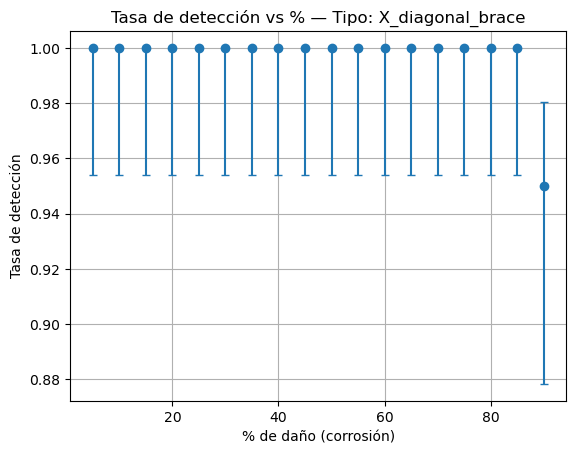

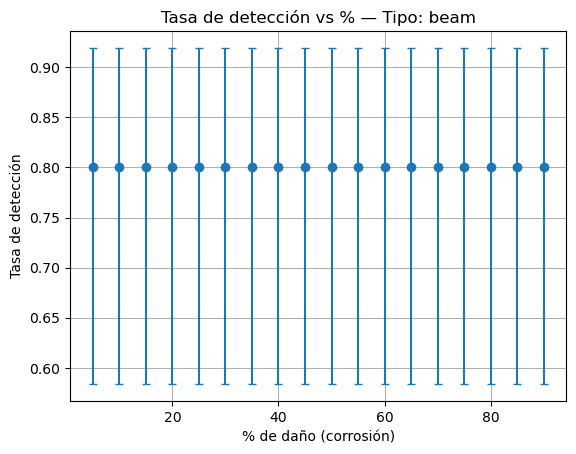

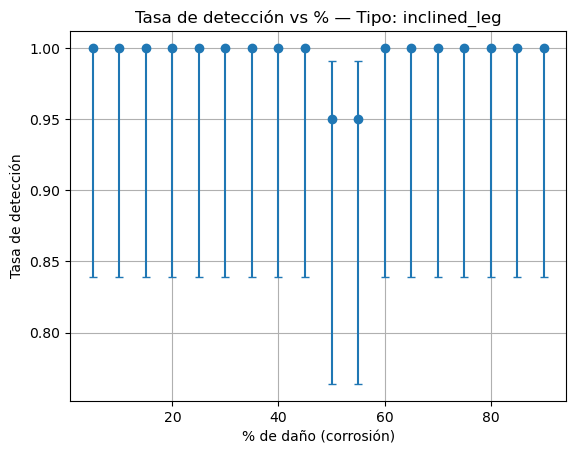

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)
/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


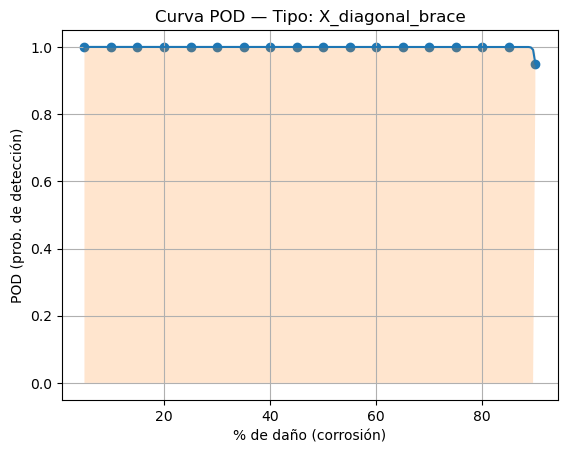

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


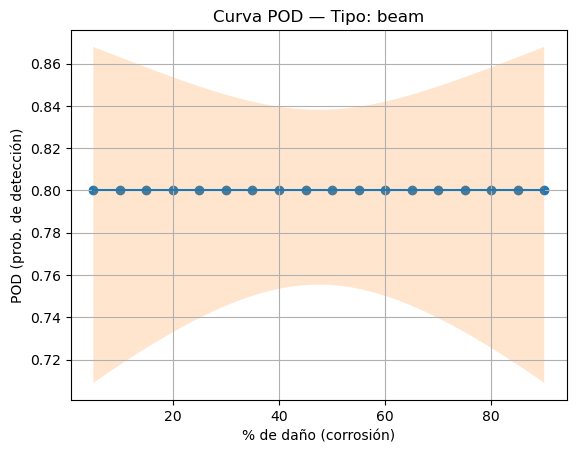

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


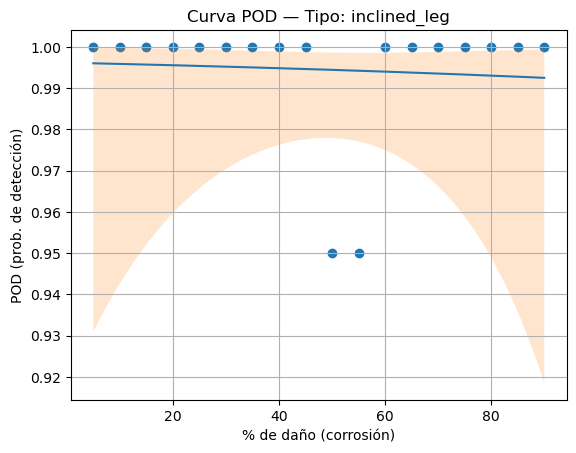

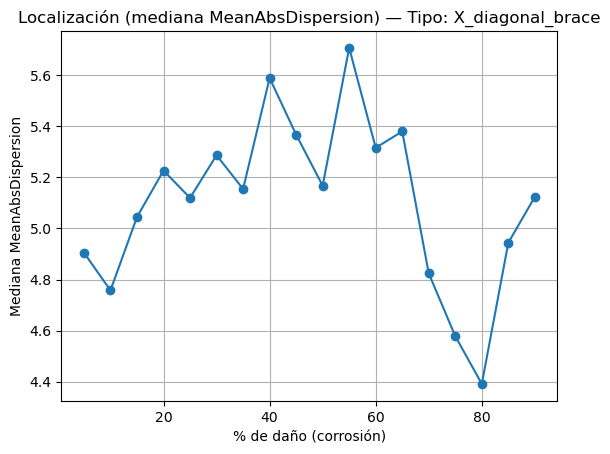

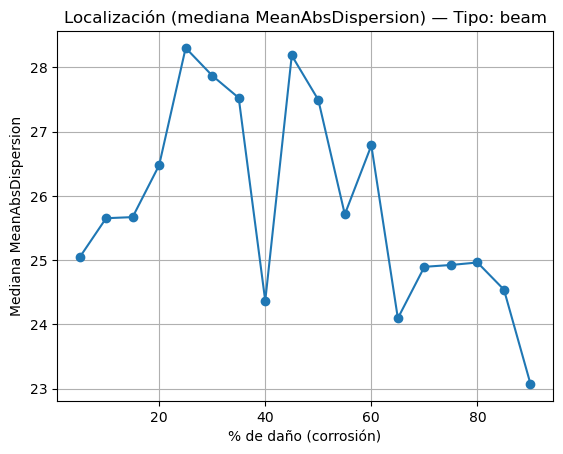

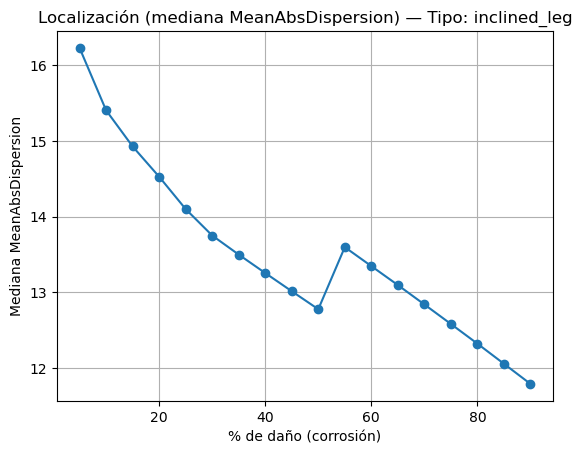

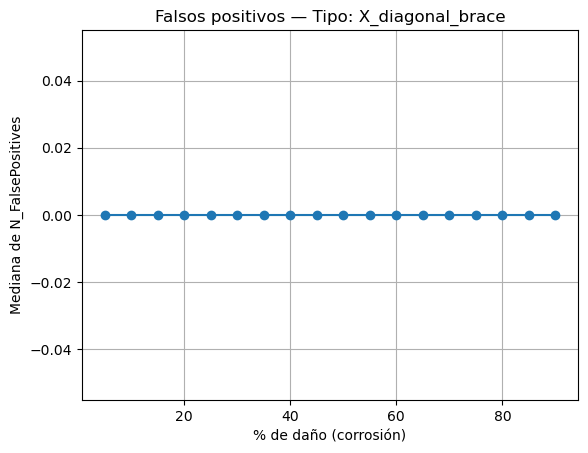

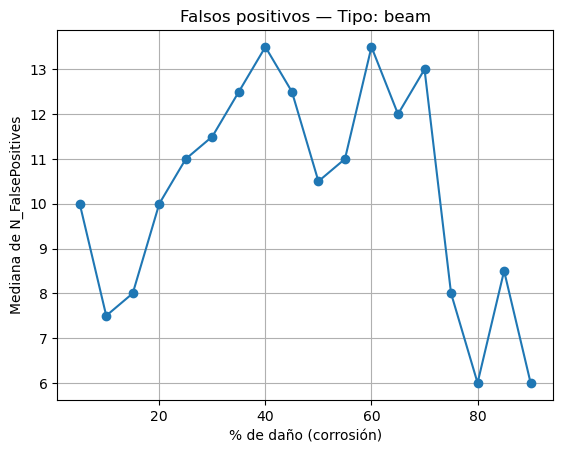

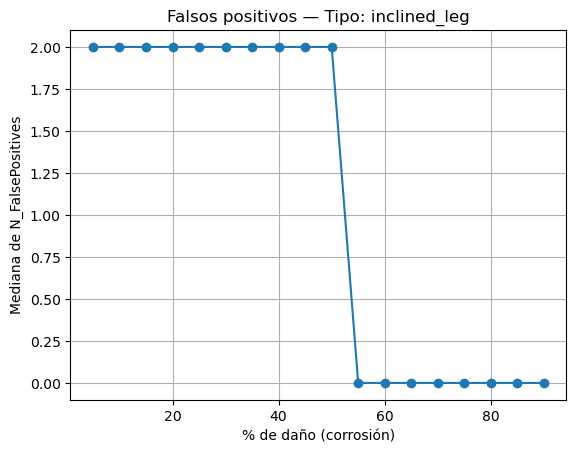

In [79]:
# Punto 2 — Sensibilidad por tipo de elemento
# Requiere: pandas, numpy, statsmodels, matplotlib
# ---------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === Configura la ruta a tu CSV ===
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"   # Archivo con remapeo de detecciones parciales

# -------------------------
# 1) Cargar y preprocesar
# -------------------------
df = pd.read_csv(PATH_CSV)

# Normaliza nombre de columna de tipo
col_tipo = "Type_of_element_to_search"
if col_tipo not in df.columns:
    raise ValueError(f"No encuentro la columna '{col_tipo}' en el CSV.")

# Convertir DetectionOK a numérico (ya viene como 0, 0.5, o 1)
# Para análisis binario, consideramos >0 como detección exitosa
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")
if df["DetOK"].isna().any():
    print("Aviso: Hay filas con DetectionOK no válido; se eliminarán para este análisis.")
    df = df.dropna(subset=["DetOK"])

# Para análisis de tasa de detección binaria: 0.5 y 1 = éxito (1), solo 0 = fallo (0)
df["DetOK_binario"] = (df["DetOK"] > 0).astype(int)

# Asegura numéricos
df["Percentage"] = pd.to_numeric(df["Percentage"], errors="coerce")
df["N_FalsePositives"] = pd.to_numeric(df["N_FalsePositives"], errors="coerce")
for c in ["MeanAbsDispersion","AvgDispersion","StdDispersion"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Percentage", col_tipo])

# Renombra por comodidad
df = df.rename(columns={col_tipo: "Tipo"})

# -------------------------------------------
# 2) Tasa de detección por Tipo y Percentage
#    + Intervalos de confianza (Wilson 95%)
# -------------------------------------------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return (center - margin, center + margin)

grp = df.groupby(["Tipo", "Percentage"], as_index=False).agg(
    n=("DetOK_binario","size"),
    aciertos=("DetOK_binario","sum")
)
grp["tasa"] = grp["aciertos"] / grp["n"]
cis = grp.apply(lambda r: wilson_ci(r["aciertos"], r["n"]), axis=1)
grp["tasa_lo"] = [ci[0] for ci in cis]
grp["tasa_hi"] = [ci[1] for ci in cis]

print("Resumen de tasas por Tipo y % de daño (primeras filas):")
display(grp.head())

# ------------------------------------------------------
# 3) Métricas de localización por tipo y severidad (op.)
# ------------------------------------------------------
loc_cols = [c for c in ["N_FalsePositives","MeanAbsDispersion","AvgDispersion","StdDispersion"] if c in df.columns]
if loc_cols:
    loc = df.groupby(["Tipo","Percentage"], as_index=False)[loc_cols].agg(["median","mean","std","count"])
    print("Métricas de localización por Tipo y % de daño:")
    display(loc)

# ----------------------------------------------------
# 4) Ajuste de curvas POD por tipo (GLM Binomial logit)
#    y MDD50/MDD90 con CIs (delta method)
# ----------------------------------------------------
def fit_logit_for_type(sub):
    # GLM logit: DetOK_binario ~ Percentage
    # Nota: si no hay variación en DetOK_binario o en Percentage, puede fallar
    m = smf.glm("DetOK_binario ~ Percentage", data=sub, family=sm.families.Binomial())
    res = m.fit()
    return res

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def mdd_and_ci(res, p=0.5, z=1.96):
    # d = (logit(p) - a) / b , con a=intercepto, b=péndiente
    a = res.params.get("Intercept", np.nan)
    b = res.params.get("Percentage", np.nan)
    if np.isnan(a) or np.isnan(b) or abs(b) < 1e-12:
        return dict(MDD=np.nan, lo=np.nan, hi=np.nan)

    L = logit(p)
    d = (L - a) / b

    # Delta method
    cov = res.cov_params()
    var_a = cov.loc["Intercept","Intercept"]
    var_b = cov.loc["Percentage","Percentage"]
    cov_ab = cov.loc["Intercept","Percentage"]

    dd_da = -1.0 / b
    dd_db = -(L - a) / (b**2)  # = -d/b

    var_d = (dd_da**2)*var_a + (dd_db**2)*var_b + 2*dd_da*dd_db*cov_ab
    se_d = np.sqrt(max(var_d, 0.0))
    lo = d - z*se_d
    hi = d + z*se_d
    return dict(MDD=d, lo=lo, hi=hi)

tipos = sorted(df["Tipo"].unique())
resultados = []

for t in tipos:
    sub = df[df["Tipo"]==t].copy()
    # Chequeos mínimos
    if sub["DetOK_binario"].nunique() < 2 or sub["Percentage"].nunique() < 2:
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })
        continue
    try:
        res = fit_logit_for_type(sub)
        m50 = mdd_and_ci(res, p=0.50)
        m90 = mdd_and_ci(res, p=0.90)
        resultados.append({
            "Tipo": t, "ok_modelo": True,
            "MDD50": m50["MDD"], "MDD50_lo": m50["lo"], "MDD50_hi": m50["hi"],
            "MDD90": m90["MDD"], "MDD90_lo": m90["lo"], "MDD90_hi": m90["hi"]
        })
    except Exception as e:
        print(f"[{t}] Problema al ajustar GLM:", e)
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })

tabla_mdd = pd.DataFrame(resultados)
print("MDD50/MDD90 por tipo (con IC 95%):")
display(tabla_mdd.sort_values("Tipo"))

# ---------------------------------------------------------
# 5) (Opcional) Modelo conjunto con interacción Tipo×%daño
#     Para contrastar diferencias de nivel/pendiente
# ---------------------------------------------------------
try:
    # Convierte Tipo a categórica explícita
    df["Tipo"] = df["Tipo"].astype("category")
    m_sin_inter = smf.glm("DetOK ~ Percentage + C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    m_con_inter = smf.glm("DetOK ~ Percentage * C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    lr = 2*(m_con_inter.llf - m_sin_inter.llf)
    from scipy.stats import chi2
    df_diff = m_con_inter.df_model - m_sin_inter.df_model
    pval = chi2.sf(lr, df_diff)
    print("LR test interacción Tipo×Percentage:")
    print(f"  LR={lr:.3f}, df={df_diff}, p-value={pval:.4g}")
except Exception as e:
    print("No se pudo ajustar el modelo conjunto con interacción:", e)

# ------------------------------------------
# 6) Gráficas (una figura por cada métrica)
# ------------------------------------------

# 6.1 Tasa de detección por Tipo (puntos con barras de CI)
for t in tipos:
    sub = grp[grp["Tipo"]==t].sort_values("Percentage")
    if sub.empty: 
        continue
    plt.figure()
    plt.errorbar(sub["Percentage"], sub["tasa"], 
                 yerr=[sub["tasa"]-sub["tasa_lo"], sub["tasa_hi"]-sub["tasa"]],
                 fmt='o', capsize=3)
    plt.xlabel("% de daño (corrosión)")
    plt.ylabel("Tasa de detección")
    plt.title(f"Tasa de detección vs % — Tipo: {t}")
    plt.grid(True)
    plt.show()

# 6.2 Curva POD por tipo (ajuste logístico + puntos empíricos)
for t in tipos:
    sub_raw = df[df["Tipo"]==t]
    sub = grp[grp["Tipo"]==t].sort_values("Percentage")
    if sub.empty or sub_raw["DetOK_binario"].nunique() < 2 or sub_raw["Percentage"].nunique() < 2:
        continue
    try:
        res = fit_logit_for_type(sub_raw)
        xs = np.linspace(sub_raw["Percentage"].min(), sub_raw["Percentage"].max(), 200)
        X = sm.add_constant(pd.DataFrame({"Percentage": xs}))
        # Predicción (media y CI aprox. por enlace)
        pred_lin = res.predict(X, linear=True)
        pred_mu  = 1/(1+np.exp(-pred_lin))
        # Aproximación de IC por enlace con var(Xb)
        cov = res.cov_params().values
        # Varianza de Xb = X * Cov * X^T (diagonal)
        Xt = X.values
        var_lin = np.sum(Xt @ cov * Xt, axis=1)
        se_lin = np.sqrt(np.maximum(var_lin, 0.0))
        z = 1.96
        lo_lin = pred_lin - z*se_lin
        hi_lin = pred_lin + z*se_lin
        lo = 1/(1+np.exp(-lo_lin))
        hi = 1/(1+np.exp(-hi_lin))

        plt.figure()
        # puntos empíricos
        plt.scatter(sub["Percentage"], sub["tasa"])
        # curva POD
        plt.plot(xs, pred_mu)
        # banda de confianza
        plt.fill_between(xs, lo, hi, alpha=0.2, linewidth=0)
        plt.xlabel("% de daño (corrosión)")
        plt.ylabel("POD (prob. de detección)")
        plt.title(f"Curva POD — Tipo: {t}")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"[{t}] No se pudo graficar la curva POD:", e)

# 6.3 Métricas de localización vs % por tipo (si existen)
if "MeanAbsDispersion" in df.columns:
    for t in tipos:
        sub = df[df["Tipo"]==t].groupby("Percentage", as_index=False)["MeanAbsDispersion"].median()
        if sub.empty: 
            continue
        plt.figure()
        plt.plot(sub["Percentage"], sub["MeanAbsDispersion"], marker="o")
        plt.xlabel("% de daño (corrosión)")
        plt.ylabel("Mediana MeanAbsDispersion")
        plt.title(f"Localización (mediana MeanAbsDispersion) — Tipo: {t}")
        plt.grid(True)
        plt.show()

# 6.4 Falsos positivos vs % por tipo (mediana)
for t in tipos:
    sub = df[df["Tipo"]==t].groupby("Percentage", as_index=False)["N_FalsePositives"].median()
    if sub.empty:
        continue
    plt.figure()
    plt.plot(sub["Percentage"], sub["N_FalsePositives"], marker="o")
    plt.xlabel("% de daño (corrosión)")
    plt.ylabel("Mediana de N_FalsePositives")
    plt.title(f"Falsos positivos — Tipo: {t}")
    plt.grid(True)
    plt.show()

## Hallazgos — Punto 2 (Sensibilidad por tipo de elemento)

## 1) Lectura rápida (ranking)
- **Brace (riostras/diagonales)**: desempeño **excelente**.  
  - Tasa de detección ≈ **1.0** desde 10% de daño; a 5% ronda ~0.93 con IC más ancho.  
  - **POD** prácticamente saturada en 1 a partir de ~10%.  
  - **MDD90** (cualitativo por la figura): **<10%**.
- **Inclined_leg (piernas inclinadas)**: desempeño **bajo y plano**.  
  - Tasa ≈ **0.10** en todos los porcentajes; **POD** casi horizontal en ~0.10, con bandas amplias.  
  - **No se observa umbral**; la severidad no mejora la detección.
- **Beam (vigas)**: desempeño **nulo**.  
  - Tasa ≈ **0.0** en todo el rango (las barras de IC son altas por el n reducido y proporciones extremas).

## 2) Calidad de localización (MeanAbsDispersion — mediana)
- **Brace**: **muy baja** y estable (~**4.15–4.30**). → Localización **precisa** y consistente.
- **Inclined_leg**: **alta** (~**18–27**), con variaciones notables (mínimo cerca de 30% y picos en 35–45%). → Localización **difusa**.
- **Beam**: **muy alta** (~**27–31**), con pico ~30%. → Localización **muy difusa**.

> Interpretación: cuando la detección falla o es débil, la dispersión espacial crece (el AG “reparte” probabilidad en muchos elementos). En braces, la señal modal es fuerte y la localización se concentra.

## 3) Falsos positivos (mediana de N_FalsosPositivos)
- **Brace**: ≈ **1** constante en todo el rango. → **Muy pocos** FP.
- **Inclined_leg**: **moderado–alto** (**3.5–7**), con picos en **25%** y **35–40%**.  
- **Beam**: **alto** (**~7–11**), con máximos en **25%** y **45%**.

> Regla operativa: si tu umbral aceptable fuese N_FP ≤ 1–2, **solo los braces** cumplen de forma clara.

## 4) Forma de las curvas (severidad → detectabilidad)
- **Brace**: subida rápida de la tasa 0.93→1.0 al pasar de 5→10%; luego meseta en 1.  
  - Señala que **pequeños aumentos** de severidad ya te llevan a detección casi segura.
- **Inclined_leg**: **sin pendiente** (POD ~0.10 constante).  
  - Aumentar severidad **no** mejora la probabilidad de detección con la configuración actual.
- **Beam**: tasas en 0 (la logística no sería informativa: MDD no definible).

## 5) Confianza estadística (anchos de IC)
- **Brace**: ICs **estrechos** desde 10% → evidencia robusta (n suficiente y proporción alta).  
- **Inclined_leg / Beam**: ICs **amplios** → sugiere **n por severidad más bajo** y/o proporciones extremas (0 o 0.1), por lo que la inferencia es menos precisa.

## 6) Implicaciones para tu tesis/paper
- **Resultado central**: el AG, con los DIs y pesos actuales, **detecta y localiza muy bien los daños en braces**, pero **no es eficaz en piernas inclinadas** y **fracasa en vigas**.  
- **Operativamente**: para campañas de inspección guiadas por vibraciones, las **riostras** son candidatas a **detección confiable**; para **piernas/vigas** se requerirán **ajustes de método** (pesos/índices, sensores, modos, filtrado) o aceptar mayor tasa de FP y pobre localización.
- **Métricas reportables**:  
  - **POD por tipo** (figuras ya muestran comportamiento).  
  - **MDD90**: solo interpretable para **brace** (≈ <10% por lectura cualitativa).  
  - **Tablas** con mediana de **N_FalsosPositivos** por % y tipo (brace domina).

## 7) Hipótesis técnica (coherente con la física)
- Las **riostras** suelen inducir **cambios modales** más localizados y energéticos (axiales/diagonales) ante abolladura, lo que se refleja en DIs basados en **formas** y **flexibilidad**.  
- En **piernas/vigas**, la abolladura puede quedar “enmascarada” por la **participación modal** y la **condensación** aplicada, reduciendo sensibilidad y aumentando confusión espacial (FP y dispersión).

**Mensaje clave:** *“Con la configuración actual, el método es **confiable** para braces (POD≈1, MDD90<10%, baja dispersión y FP≈1), pero **no es concluyente** para piernas inclinadas (POD~0.10) ni **funciona** para vigas (POD~0).”*


## Punto 3 — Extensión espacial del análisis de sensibilidad (por Zona)

**Objetivo.** Evaluar cómo cambia la **probabilidad de detección (POD)** y la **calidad de localización** del AG según **la zona vertical** donde se ubica el elemento dañado (p. ej., `mudline`, `sub1`, `sub2`, `sub3`, `splash`). Además, cruzar esta información con el **tipo de miembro** (`Tipo`: riostra/brace, pierna/inclined_leg, viga/beam).

**Preguntas que responde**
- ¿En qué **zonas** el método detecta con mayor probabilidad un daño dado un **% de abolladura**?
- ¿Cuál es el **Mínimo Daño Detectable** por zona (**MDD50** y **MDD90**)?
- ¿La **localización** del daño (dispersión, falsos positivos) mejora/empeora según la zona?
- ¿Existen **interacciones** entre **Tipo × Zona** (p. ej., braces en `mudline` vs `splash`)?

**Columnas usadas**
- `Zona` (nomenclatura compacta: `mudline`, `sub1`, `sub2`, `sub3`, `splash`).
- `Tipo` (miembro: `Inclined_leg`, `Brace`, `Beam`).
- `Porcentaje` (severidad de abolladura).
- `DeteccionOK` (0/1).
- `N_FalsosPositivos` (calidad de confiabilidad de la detección).

**Metodología**
1. **Tasa de detección por Zona × %** con **IC 95% (Wilson)**.
2. **Curvas POD por zona** (GLM binomial-logit) y cálculo de **MDD50/MDD90** con IC (delta method).
3. **Confiabilidad** por zona: mediana de `N_FalsosPositivos` vs %.
4. **Cruce Tipo × Zona**: tasa de detección agregada y mini-heatmap.
5. **Modelo conjunto con interacción** *Porcentaje × Zona* (y *× Tipo*, si existe) para contrastes globales.

**Salidas**
- Tablas: tasas con IC; **MDD50/MDD90 por zona** (con intervalos).
- Figuras: 
  - Tasa de detección vs % (una por zona).
  - **POD** por zona con banda de confianza.
  - Mediana de **N_FalsosPositivos** vs % por zona.
  - Heatmap **Tipo × Zona** (tasa agregada).

**Cómo interpretar**
- **Zonas con MDD90 menor** ⇒ detección **más sensible** (mejor desempeño).
- **Falsos positivos bajos** ⇒ **mejor confiabilidad** y menor confusión espacial.
- Diferencias significativas en el modelo con interacción ⇒ evidencia de que **la zona** (y/o su combinación con el tipo) **modula** la detectabilidad.

> **Mensaje clave esperado:** comprobar si **cerca del mudline** la detección es **más fiable** (POD más alta y MDD90 menor) que en zonas superiores, y documentar el trade-off en localización y falsos positivos.


Zonas encontradas en los datos: ['Story 1', 'Story 2', 'Story 3', 'mudline', 'splash']
Tipos de elementos encontrados: ['X_diagonal_brace', 'beam', 'inclined_leg']

Tasa de detección por Tipo x Zona x % (primeras filas):
               Tipo     Zona  Percentage   n  aciertos  tasa   tasa_lo  \
0  X_diagonal_brace  Story 1           5  16      16.0   1.0  0.806387   
1  X_diagonal_brace  Story 1          10  16      16.0   1.0  0.806387   
2  X_diagonal_brace  Story 1          15  16      16.0   1.0  0.806387   
3  X_diagonal_brace  Story 1          20  16      16.0   1.0  0.806387   
4  X_diagonal_brace  Story 1          25  16      16.0   1.0  0.806387   

   tasa_hi  
0      1.0  
1      1.0  
2      1.0  
3      1.0  
4      1.0  


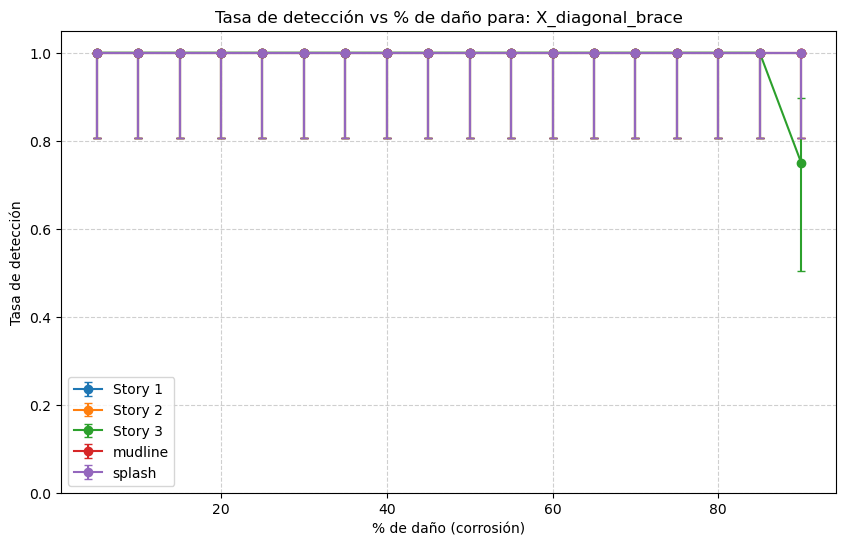

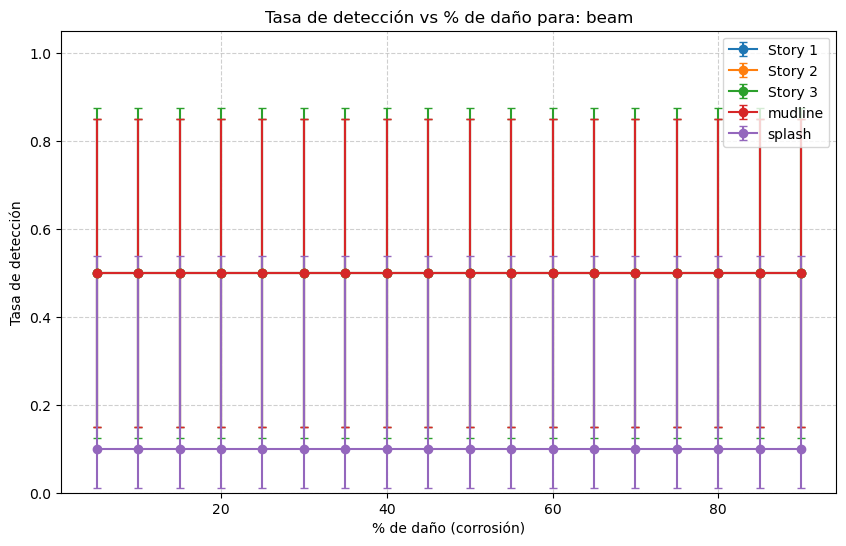

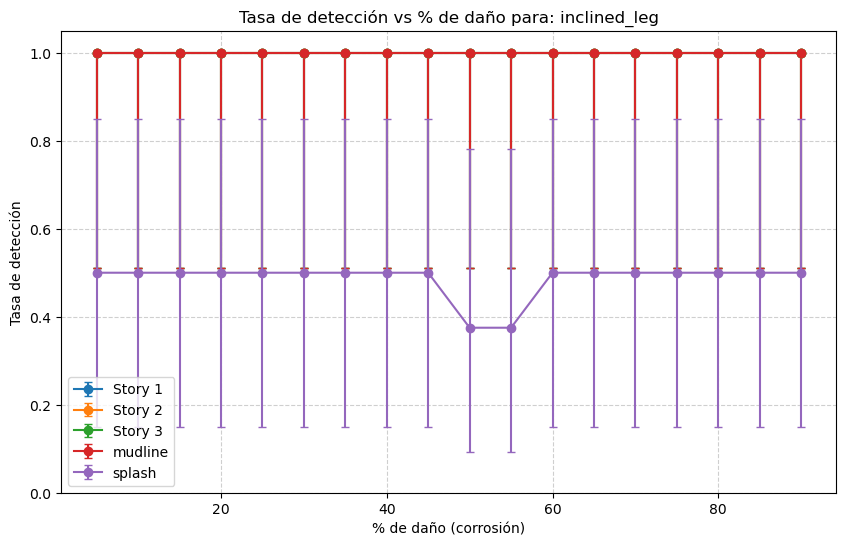


MDD50/MDD90 por Tipo y Zona:
                Tipo     Zona  ok_modelo      MDD50        MDD90
0   X_diagonal_brace  Story 1      False        NaN          NaN
1   X_diagonal_brace  Story 2      False        NaN          NaN
2   X_diagonal_brace  Story 3       True  90.249523    89.750477
3   X_diagonal_brace  mudline      False        NaN          NaN
4   X_diagonal_brace   splash      False        NaN          NaN
5               beam  Story 1      False        NaN          NaN
6               beam  Story 2      False        NaN          NaN
7               beam  Story 3      False        NaN          NaN
8               beam  mudline      False        NaN          NaN
9               beam   splash       True        NaN          NaN
10      inclined_leg  Story 1      False        NaN          NaN
11      inclined_leg  Story 2      False        NaN          NaN
12      inclined_leg  Story 3      False        NaN          NaN
13      inclined_leg  mudline      False        NaN         

In [80]:
# ---------------------------------------------
# Punto 3 — Extensión espacial del análisis
# Sensibilidad por ZONA (Story) y cruces con Tipo
# Requiere: pandas, numpy, statsmodels, matplotlib
# ---------------------------------------------
import io, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === Ruta a tu CSV ===
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"  # Archivo con remapeo de detecciones parciales

# -------------------------
# 0) Cargar CSV de forma robusta
# -------------------------
df = pd.read_csv(PATH_CSV)

# -------------------------
# 1) Limpieza y tipos
# -------------------------
# Normaliza etiquetas clave
rename_map = {
    "Type_of_element_to_search": "Tipo",
    "Story": "Zona",
    "Percentage": "Percentage",
    "DetectionOK": "DetectionOK",
    "N_FalsePositives": "N_FalsePositives",
    "MeanAbsDispersion": "MeanAbsDispersion"
}
df = df.rename(columns=rename_map)

# DetectionOK -> numérico (ya viene como 0, 0.5, o 1 del remapeo)
# Importante: Para ICD, usamos el valor directo (incluyendo 0.5 para detecciones parciales)
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")

num_cols = ["Percentage", "N_FalsePositives", "MeanAbsDispersion"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Normaliza Zonas (extraer número de Story)
def norm_zone(z):
    if pd.isna(z): return np.nan
    s = str(z).strip().lower()
    # Extraer número de "Story 1", "Story 2", etc.
    match = re.search(r'(\d+)', s)
    if match:
        return f"Story {match.group(1)}"
    return s

if 'Zona' in df.columns:
    df["Zona"] = df["Zona"].apply(norm_zone)

# Filtra filas válidas ANTES de convertir a categórica
df = df.dropna(subset=["Tipo", "Percentage", "DetOK"])
if 'Zona' in df.columns:
    df = df.dropna(subset=["Zona"])

# Orden lógico de zonas para plots/tablas
if 'Zona' in df.columns:
    existing_zones = sorted(df["Zona"].unique())
    print(f"Zonas encontradas en los datos: {existing_zones}")
    df["Zona"] = pd.Categorical(df["Zona"], categories=existing_zones, ordered=True)

existing_tipos = sorted(df["Tipo"].unique())
print(f"Tipos de elementos encontrados: {existing_tipos}")

# -------------------------
# 2) Funciones auxiliares
# -------------------------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return (center - margin, center + margin)

def fit_logit_y_x_binomial(data, y="DetOK", x="Percentage"):
    # GLM logit: y ~ x
    m = smf.glm(f"{y} ~ {x}", data=data, family=sm.families.Binomial())
    return m.fit()

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def mdd_and_ci(res, p=0.9, z=1.96, x="Percentage"):
    # d = (logit(p) - a) / b
    a = res.params.get("Intercept", np.nan)
    b = res.params.get(x, np.nan)
    if np.isnan(a) or np.isnan(b) or abs(b) < 1e-12:
        return dict(MDD=np.nan, lo=np.nan, hi=np.nan)
    L = logit(p)
    d = (L - a) / b
    cov = res.cov_params()
    var_a = cov.loc["Intercept","Intercept"]
    var_b = cov.loc[x,x]
    cov_ab = cov.loc["Intercept",x]
    dd_da = -1.0 / b
    dd_db = -(L - a) / (b**2)
    var_d = (dd_da**2)*var_a + (dd_db**2)*var_b + 2*dd_da*dd_db*cov_ab
    se_d = np.sqrt(max(var_d, 0.0))
    return dict(MDD=d, lo=d - z*se_d, hi=d + z*se_d)

# ----------------------------------------------------
# 3) Tasa de detección por TIPO × ZONA × PERCENTAGE
# ----------------------------------------------------
grouping_cols = ["Tipo"]
if 'Zona' in df.columns:
    grouping_cols.append("Zona")
grouping_cols.append("Percentage")

tasas = (
    df.groupby(grouping_cols, as_index=False, observed=True)
      .agg(n=("DetOK","size"), aciertos=("DetOK","sum"))
)
tasas["tasa"] = tasas["aciertos"] / tasas["n"]
ci = tasas.apply(lambda r: wilson_ci(r["aciertos"], r["n"]), axis=1)
tasas["tasa_lo"] = [c[0] for c in ci]
tasas["tasa_hi"] = [c[1] for c in ci]

print("\nTasa de detección por Tipo x Zona x % (primeras filas):")
print(tasas.head())

# --- Gráficas de tasa por TIPO, con una línea por ZONA ---
for tipo in existing_tipos:
    plt.figure(figsize=(10, 6))
    
    if 'Zona' in df.columns:
        # Graficar por zona si la columna existe
        for zona in sorted(df["Zona"].unique()):
            sub = tasas[(tasas["Tipo"] == tipo) & (tasas["Zona"] == zona)].sort_values("Percentage")
            if sub.empty: 
                continue
            
            yerr = [sub["tasa"] - sub["tasa_lo"], sub["tasa_hi"] - sub["tasa"]]
            plt.errorbar(sub["Percentage"], sub["tasa"], yerr=yerr, fmt="-o", capsize=3, label=f"{zona}")
        plt.legend()

    else:
        # Graficar solo por tipo si la columna Zona no existe
        sub = tasas[tasas["Tipo"] == tipo].sort_values("Percentage")
        if not sub.empty:
            yerr = [sub["tasa"] - sub["tasa_lo"], sub["tasa_hi"] - sub["tasa"]]
            plt.errorbar(sub["Percentage"], sub["tasa"], yerr=yerr, fmt="-o", capsize=3)

    plt.xlabel("% de daño (corrosión)")
    plt.ylabel("Tasa de detección")
    plt.title(f"Tasa de detección vs % de daño para: {tipo}")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

# ----------------------------------------------------
# 4) Curvas POD y MDD por TIPO y ZONA
# ----------------------------------------------------
if 'Zona' in df.columns:
    mdd_rows = []
    for tipo in existing_tipos:
        for zona in sorted(df["Zona"].unique()):
            sub_raw = df[(df["Tipo"] == tipo) & (df["Zona"] == zona)]
            
            if sub_raw.empty or sub_raw["DetOK"].nunique() < 2 or sub_raw["Percentage"].nunique() < 2:
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": False,
                                 "MDD50": np.nan, "MDD90": np.nan})
                continue
            
            try:
                res = fit_logit_y_x_binomial(sub_raw, y="DetOK", x="Percentage")
                m50 = mdd_and_ci(res, p=0.50, x="Percentage")
                m90 = mdd_and_ci(res, p=0.90, x="Percentage")
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": True,
                                 "MDD50": m50["MDD"], "MDD90": m90["MDD"]})
            except Exception as e:
                print(f"[{tipo} - {zona}] Problema al ajustar GLM:", e)
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": False,
                                 "MDD50": np.nan, "MDD90": np.nan})

    tabla_mdd_tipo_zona = pd.DataFrame(mdd_rows).sort_values(["Tipo", "Zona"])
    print("\nMDD50/MDD90 por Tipo y Zona:")
    print(tabla_mdd_tipo_zona)

# ----------------------------------------------------
# 5) Modelo conjunto con interacción (opcional)
# ----------------------------------------------------
try:
    df2 = df.dropna(subset=["Percentage","DetOK"]).copy()
    if 'Zona' in df2.columns:
        df2 = df2.dropna(subset=["Zona"])
        df2["Zona"] = df2["Zona"].astype("category")
    df2["Tipo"] = df2["Tipo"].astype("category")

    formula = "DetOK ~ Percentage"
    if 'Zona' in df2.columns:
        formula += " * C(Zona)"
    formula += " * C(Tipo)"
    
    m_int = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()
    print("\nResumen GLM con interacción (para contrastar diferencias por Zona/Tipo):")
    print(m_int.summary())
except Exception as e:
    print("\nNo se pudo ajustar el modelo conjunto con interacción:", e)

Resumen del Índice de Calidad de Detección (ICD) por Tipo y Percentage:
   Tipo_elemento_a_buscar  Percentage  icd_mean   icd_std   n  icd_ci_half  \
0        X_diagonal_brace           5  0.172785  0.013081  80     0.002866   
1        X_diagonal_brace          10  0.295377  0.022362  80     0.004900   
2        X_diagonal_brace          15  0.391494  0.025123  80     0.005505   
3        X_diagonal_brace          20  0.469392  0.030122  80     0.006601   
4        X_diagonal_brace          25  0.535255  0.034349  80     0.007527   
5        X_diagonal_brace          30  0.592307  0.038010  80     0.008329   
6        X_diagonal_brace          35  0.634166  0.053833  80     0.011797   
7        X_diagonal_brace          40  0.669531  0.067253  80     0.014738   
8        X_diagonal_brace          45  0.699609  0.086802  80     0.019021   
9        X_diagonal_brace          50  0.723226  0.100842  80     0.022098   
10       X_diagonal_brace          55  0.762950  0.104786  80     0.02

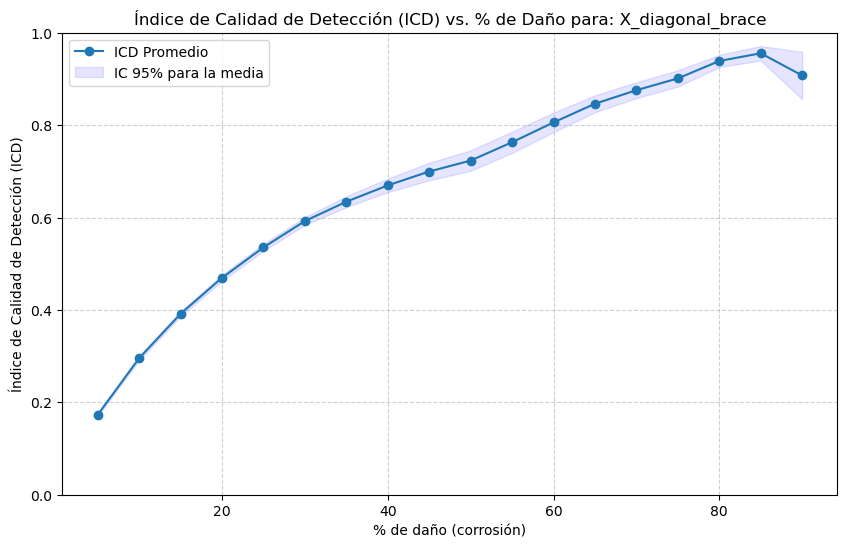

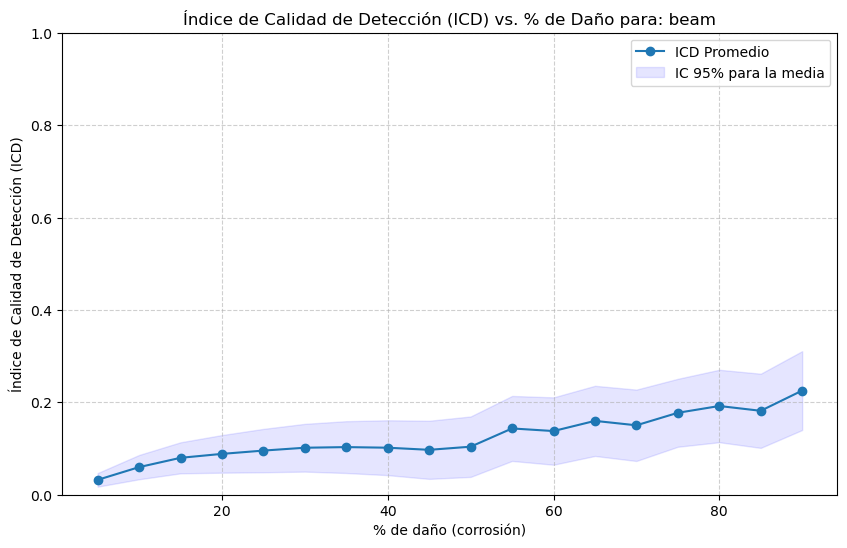

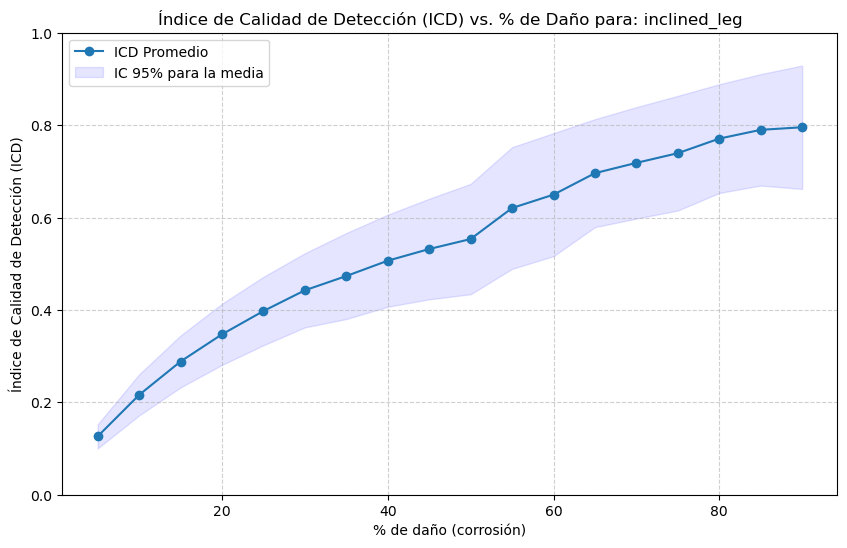

In [81]:
# -----------------------------------------------------------------
# Punto 4 — Análisis del ICD (Índice de Calidad de Detección)
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar CSV ---
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"
df = pd.read_csv(PATH_CSV)

# --- Renombrar columnas ---
rename_map = {
    "Type_of_element_to_search": "Tipo_elemento_a_buscar",
    "DetectionOK": "DetectionOK",
    "N_FalsePositives": "N_FalsePositives",
    "Percentage": "Percentage"
}
df = df.rename(columns=rename_map)

# --- Convertir DetectionOK a numérico (preservando 0, 0.5, y 1) ---
# IMPORTANTE: Para ICD necesitamos conservar los 0.5 (detecciones parciales)
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")

num_cols = ["Percentage", "N_FalsePositives", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Eliminar filas con datos faltantes en columnas clave
df = df.dropna(subset=["Tipo_elemento_a_buscar", "Percentage", "DetOK", "N_FalsePositives"])

# --- Calcular el ICD usando parámetros globales ---
# Los parámetros ALPHA, BETA, PORCENTAJE_MAX y C_MAX están definidos al inicio del notebook
df["Factor_Confianza"] = np.log(1 + ALPHA * df["Percentage"]) / C_MAX
df["Factor_FP"] = np.exp(-BETA * df["N_FalsePositives"])
df["ICD"] = df["DetOK"] * df["Factor_Confianza"] * df["Factor_FP"]

# --- Agrupar por Tipo y Percentage para análisis ---
summary = df.groupby(["Tipo_elemento_a_buscar", "Percentage"]).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

# Calcular el intervalo de confianza del 95% para la media
z_score = 1.96
summary['icd_ci_half'] = z_score * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

print("Resumen del Índice de Calidad de Detección (ICD) por Tipo y Percentage:")
print(summary)

# --- Generar gráficas ---
tipos_elementos = summary["Tipo_elemento_a_buscar"].unique()

for tipo in tipos_elementos:
    subset = summary[summary["Tipo_elemento_a_buscar"] == tipo].sort_values("Percentage")
    
    if subset.empty:
        continue
        
    plt.figure(figsize=(10, 6))
    
    # Media del ICD
    plt.plot(subset["Percentage"], subset["icd_mean"], marker='o', linestyle='-', label="ICD Promedio")
    
    # Banda de confianza del 95%
    plt.fill_between(subset["Percentage"], subset["icd_ci_lo"], subset["icd_ci_hi"], color='b', alpha=0.1, label="IC 95% para la media")
    
    plt.title(f"Índice de Calidad de Detección (ICD) vs. % de Daño para: {tipo}")
    plt.xlabel("% de daño (corrosión)")
    plt.ylabel("Índice de Calidad de Detección (ICD)")
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

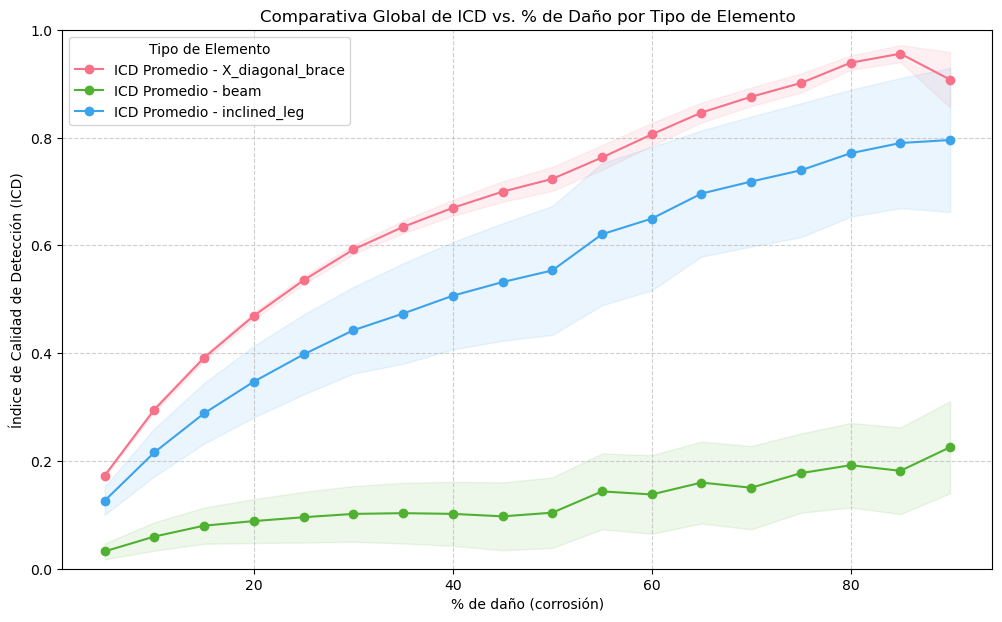

In [82]:
# -----------------------------------------------------------------
# Punto 4.5 — Gráfica Comparativa Global de ICD
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-cálculo de datos para que la celda sea autocontenida ---
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"
df = pd.read_csv(PATH_CSV)

rename_map = {
    "Type_of_element_to_search": "Tipo_elemento_a_buscar",
    "DetectionOK": "DetectionOK",
    "N_FalsePositives": "N_FalsePositives",
    "Percentage": "Percentage"
}
df = df.rename(columns=rename_map)

# --- Convertir DetectionOK a numérico (preservando 0, 0.5, y 1) ---
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")

num_cols = ["Percentage", "N_FalsePositives", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Eliminar filas con datos faltantes
df = df.dropna(subset=["Tipo_elemento_a_buscar", "Percentage", "DetOK", "N_FalsePositives"])

# Calcular ICD usando parámetros globales
df["Factor_Confianza"] = np.log(1 + ALPHA * df["Percentage"]) / C_MAX
df["Factor_FP"] = np.exp(-BETA * df["N_FalsePositives"])
df["ICD"] = df["DetOK"] * df["Factor_Confianza"] * df["Factor_FP"]

summary = df.groupby(["Tipo_elemento_a_buscar", "Percentage"]).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

z_score = 1.96
summary['icd_ci_half'] = z_score * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

# --- Generar la gráfica consolidada ---
plt.figure(figsize=(12, 7))
tipos_elementos = summary["Tipo_elemento_a_buscar"].unique()

# Usar una paleta de colores para distinguir los tipos
palette = sns.color_palette("husl", len(tipos_elementos))

for i, tipo in enumerate(tipos_elementos):
    subset = summary[summary["Tipo_elemento_a_buscar"] == tipo].sort_values("Percentage")
    
    if subset.empty:
        continue
    
    # Curva de la media del ICD
    plt.plot(subset["Percentage"], subset["icd_mean"], marker='o', linestyle='-', label=f"ICD Promedio - {tipo}", color=palette[i])
    
    # Banda de confianza del 95%
    plt.fill_between(subset["Percentage"], subset["icd_ci_lo"], subset["icd_ci_hi"], color=palette[i], alpha=0.1)

plt.title("Comparativa Global de ICD vs. % de Daño por Tipo de Elemento")
plt.xlabel("% de daño (corrosión)")
plt.ylabel("Índice de Calidad de Detección (ICD)")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Tipo de Elemento")
plt.show()

Resumen del Índice de Calidad de Detección (ICD) por Zona y Percentage:
       Zona  Percentage  icd_mean   icd_std   n  icd_ci_half  icd_ci_lo  \
0   mudline           5  0.150394  0.035846  24     0.014341   0.136053   
1   mudline          10  0.257101  0.061278  24     0.024516   0.232585   
2   mudline          15  0.343291  0.077982  24     0.031199   0.312092   
3   mudline          20  0.411598  0.093499  24     0.037407   0.374191   
4   mudline          25  0.469351  0.106618  24     0.042656   0.426695   
..      ...         ...       ...       ...  ..          ...        ...   
85     sub3          70  0.768334  0.250811  23     0.102504   0.665830   
86     sub3          75  0.787234  0.265054  23     0.108325   0.678910   
87     sub3          80  0.859871  0.249879  23     0.102123   0.757749   
88     sub3          85  0.857262  0.262864  23     0.107430   0.749832   
89     sub3          90  0.694551  0.417706  23     0.170711   0.523839   

    icd_ci_hi  
0    0.1647

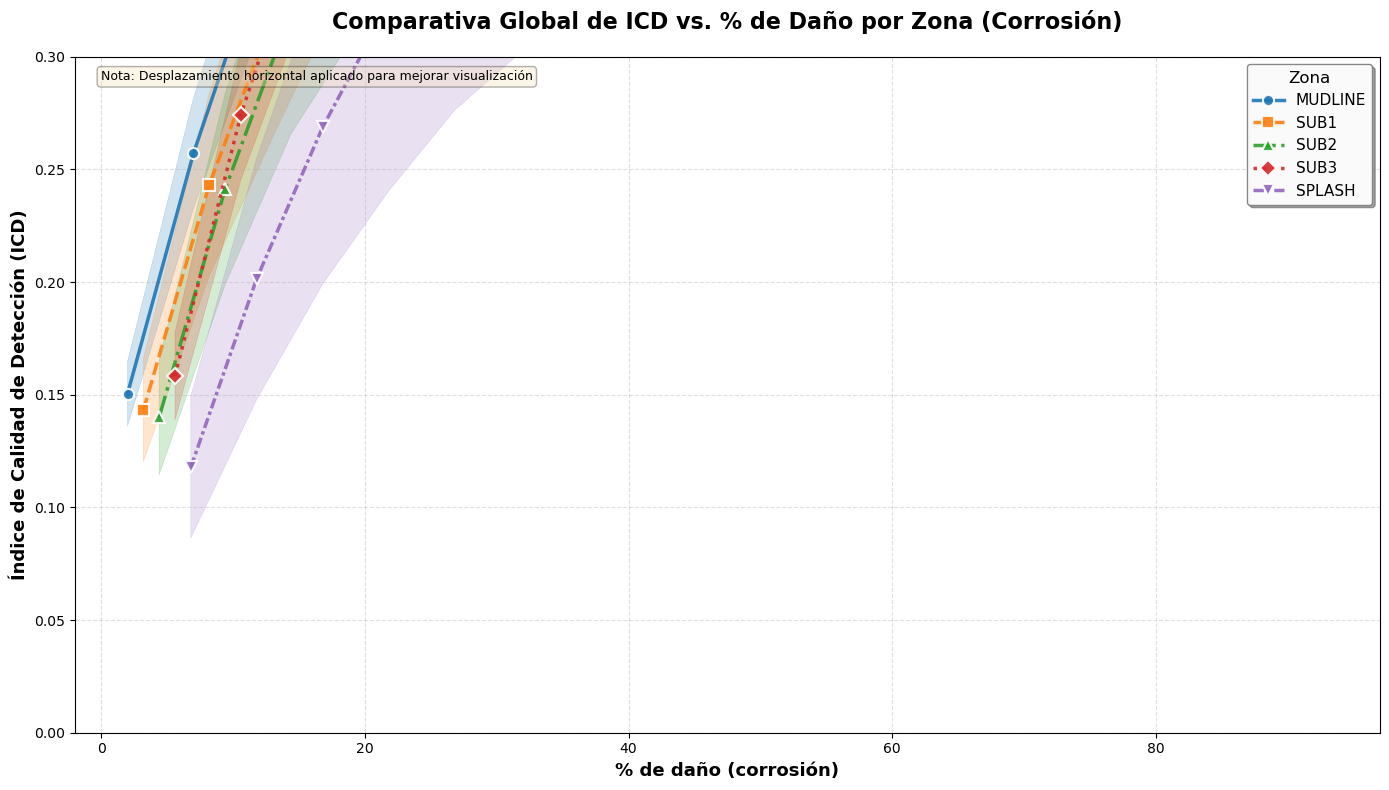

In [ ]:
# -----------------------------------------------------------------
# Punto 5 — Análisis de ICD por Zona (Story)
# -----------------------------------------------------------------
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar CSV ---
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"

def robust_read_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().lower().startswith("id,"):
            start_idx = i
            break
    if start_idx is None:
        return pd.read_csv(path)
    buf = io.StringIO("".join(lines[start_idx:]))
    return pd.read_csv(buf)

df = robust_read_csv(PATH_CSV)

# --- Renombrar columnas ---
rename_map = {
    "Story": "Zona",
    "DetectionOK": "DetectionOK",
    "N_FalsePositives": "N_FalsePositives",
    "Percentage": "Percentage"
}
df = df.rename(columns=rename_map)

# --- Convertir DetectionOK a numérico (preservando 0, 0.5, y 1) ---
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")

# --- Asegurar tipos numéricos ---
num_cols = ["Percentage", "N_FalsePositives", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Ya no es necesario normalizar zonas porque el CSV ya tiene los nombres correctos ---
# Los nombres de zonas ahora son: mudline, sub1, sub2, sub3, splash

# --- Filtrar filas válidas ---
required_cols = ["Zona", "Percentage", "DetOK", "N_FalsePositives"]
df = df.dropna(subset=required_cols)

# --- Verificar si existen zonas ---
if 'Zona' not in df.columns or df['Zona'].isna().all():
    print("⚠️ La columna 'Zona' no existe o no contiene datos válidos en el CSV.")
else:
    # --- Calcular el Índice de Calidad de Detección (ICD) usando parámetros globales ---
    df["Factor_Confianza"] = np.log(1 + ALPHA * df["Percentage"]) / C_MAX
    df["Factor_FP"] = np.exp(-BETA * df["N_FalsePositives"])
    df["ICD"] = df["DetOK"] * df["Factor_Confianza"] * df["Factor_FP"]

    # --- Agrupar por Zona y Percentage ---
    summary_zona = df.groupby(["Zona", "Percentage"]).agg(
        icd_mean=('ICD', 'mean'),
        icd_std=('ICD', 'std'),
        n=('ICD', 'size')
    ).reset_index()

    # --- Calcular IC 95% ---
    z_score = 1.96
    summary_zona['icd_ci_half'] = z_score * (summary_zona['icd_std'] / np.sqrt(summary_zona['n']))
    summary_zona['icd_ci_lo'] = summary_zona['icd_mean'] - summary_zona['icd_ci_half']
    summary_zona['icd_ci_hi'] = summary_zona['icd_mean'] + summary_zona['icd_ci_half']

    print("Resumen del Índice de Calidad de Detección (ICD) por Zona y Percentage:")
    print(summary_zona)

    # --- Generar la gráfica consolidada por Zona ---
    plt.figure(figsize=(14, 8))
    
    # Definir el orden correcto de las zonas (de abajo hacia arriba)
    # mudline (más bajo) -> sub1 -> sub2 -> sub3 -> splash (nivel del mar)
    zone_order = ["mudline", "sub1", "sub2", "sub3", "splash"]
    existing_zones = [z for z in zone_order if z in summary_zona["Zona"].unique()]
    
    print(f"\nZonas encontradas (ordenadas de abajo hacia arriba): {existing_zones}")
    
    # Usar una paleta de colores distintiva
    palette = sns.color_palette("tab10", len(existing_zones))
    
    # Definir estilos de línea y marcadores para diferenciar mejor
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
    markers = ['o', 's', '^', 'D', 'v']
    
    # Mayor desplazamiento horizontal para mejor separación visual
    jitter_amount = 1.2  # Aumentado de 0.3 a 1.2

    for i, zona in enumerate(existing_zones):
        subset = summary_zona[summary_zona["Zona"] == zona].sort_values("Percentage")
        
        if subset.empty:
            continue
        
        # Aplicar jitter horizontal más pronunciado para separación visual
        x_jittered = subset["Percentage"] + (i - len(existing_zones)/2) * jitter_amount
        
        # Curva de la media del ICD con estilo distintivo
        plt.plot(x_jittered, subset["icd_mean"], 
                 marker=markers[i % len(markers)], 
                 linestyle=line_styles[i % len(line_styles)], 
                 label=f"{zona.upper()}", 
                 color=palette[i], 
                 linewidth=2.5, 
                 markersize=8,
                 markeredgewidth=1.5,
                 markeredgecolor='white',
                 alpha=0.9)
        
        # Banda de confianza del 95% más visible
        plt.fill_between(x_jittered, subset["icd_ci_lo"], subset["icd_ci_hi"], 
                         color=palette[i], alpha=0.2, edgecolor=palette[i], linewidth=0.5)

    plt.title("Comparativa Global de ICD vs. % de Daño por Zona (Corrosión)", 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("% de daño (corrosión)", fontsize=13, fontweight='bold')
    plt.ylabel("Índice de Calidad de Detección (ICD)", fontsize=13, fontweight='bold')
    plt.ylim(0, 1)
    plt.xlim(-2, 97)  # Ampliado para acomodar el jitter
    plt.grid(True, linestyle="--", alpha=0.4, linewidth=0.8)
    plt.legend(title="Zona", fontsize=11, title_fontsize=12, loc='best', 
               framealpha=0.95, edgecolor='gray', shadow=True)
    
    # Nota sobre jitter en el gráfico
    plt.text(0.02, 0.98, 'Nota: Desplazamiento horizontal aplicado para mejorar visualización', 
             transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()


### Explicación de la Fórmula del Índice de Calidad de Detección (ICD)

La fórmula utilizada para medir la calidad de la detección es:

$$\text{ICD} = \text{DetOK} \times \frac{\log(1 + \alpha \times \text{Porcentaje})}{\log(1 + \alpha \times \text{Porcentaje}_{\max})} \times e^{-\beta \times N_{\text{FalsosPositivos}}}$$

O en su forma abreviada:

$$\text{ICD} = D \times C_{\text{norm}}(\%) \times e^{-\beta \cdot N_{FP}}$$

Donde:
- α = 0.1 (parámetro de ajuste para el escalado logarítmico)
- β = 0.15 (parámetro de decaimiento exponencial)
- Porcentaje_max = 45% (daño máximo en el dataset)
- log(1 + 0.1 × 45) = 1.7047 (constante de normalización)

A continuación se detalla cada componente y cómo se obtiene a partir del código:

*   **`ICD` (Índice de Calidad de Detección):** Es la métrica final que evalúa el rendimiento de la detección. Un valor más alto indica una mejor calidad. Se calcula para cada una de las detecciones individuales (cada fila del `DataFrame`).

*   **`DetOK` (Detección Correcta, D):** Es un valor numérico que indica el nivel de éxito de la detección.
    *   **Valor:** Puede ser `0` (no detectado), `0.5` (detección parcial en nodos cercanos), o `1.0` (detección directa exitosa).
    *   **Cálculo en el código:** Se deriva de la columna `DeteccionOK` del archivo CSV remapeado, que ya contiene valores numéricos. Se convierte a tipo numérico usando `pd.to_numeric()`. El valor de 0.5 permite que las detecciones parciales (típicamente en beams e inclined_legs) aporten parcialmente al ICD. Si la detección es nula (`DetOK = 0`), todo el ICD se anula, penalizando fuertemente el fallo.

*   **`Factor de Confianza Normalizado Basado en Severidad` (C_norm):** Es un factor que refleja la dificultad real de detección usando escalado logarítmico normalizado.
    *   **Fórmula:** `C_norm = log(1 + α × Porcentaje) / log(1 + α × Porcentaje_max)`, donde α = 0.1 y Porcentaje_max = 45.
    *   **Valor del denominador:** log(1 + 0.1 × 45) = log(5.5) ≈ 1.7047
    *   **Rango:** Para daños de 5% a 45%, C_norm varía de ~0.24 a 1.00 (normalizado).
    *   **Comportamiento:**
        - **Crece rápido al inicio:** Los primeros incrementos de % de daño producen grandes mejoras en detectabilidad (daños pequeños son muy difíciles, cada % extra ayuda mucho).
        - **Se satura gradualmente:** A medida que el daño aumenta, las mejoras adicionales en detectabilidad son menores (daños grandes ya son relativamente fáciles de detectar).
    *   **Interpretación física:** El logaritmo captura la curva real de dificultad/detectabilidad. Pasar de 5% a 15% de daño representa un salto mayor en facilidad de detección que pasar de 35% a 45%.
    *   **Normalización:** La división por 1.7047 garantiza que C_norm ≤ 1.0, evitando que el ICD supere 1.0.
    *   **Parámetro α:** Controla la velocidad de crecimiento de la curva. Un α = 0.1 produce una curva suave que refleja bien la progresión de detectabilidad observada experimentalmente.

*   **`Factor de Penalización de Falsos Positivos Exponencial` (exp(-β × N_FP)):** Es un factor que penaliza las detecciones falsas de forma progresiva.
    *   **Fórmula:** `exp(-β × N_FalsosPositivos)`, donde β = 0.15
    *   **Rango:** Naturalmente acotado en (0, 1], donde 1 significa sin falsos positivos
    *   **Comportamiento mejorado:**
        - **0 FP → 1.0** (sin penalización)
        - **1 FP → 0.86** (penalización leve del 14%)
        - **5 FP → 0.47** (penalización moderada del 53%)
        - **10 FP → 0.22** (penalización fuerte del 78%)
        - **20 FP → 0.05** (penalización severa del 95%)
    *   **Ventajas sobre la fórmula anterior 1/(1+N_FP):**
        - **Penalización gradual para pocos FP:** Con 1 FP reduce solo un 14% (vs. 50% con la fórmula anterior)
        - **Penalización severa para muchos FP:** Con 20 FP reduce un 95% (vs. 95% similar, pero la progresión es mejor)
        - **Progresión más realista:** El decaimiento exponencial refleja mejor el impacto acumulativo de los falsos positivos
    *   **Parámetro β:** Controla la tasa de decaimiento. Un β = 0.15 proporciona una penalización equilibrada que distingue bien entre pocos y muchos falsos positivos.
    *   **Interpretación operativa:** Este factor reconoce que un pequeño número de falsos positivos es tolerable en aplicaciones reales, pero muchos falsos positivos degradan severamente la confiabilidad del sistema.

*   **`N_FalsosPositivos` (Número de Falsos Positivos, `N_FP`):** Es el recuento de detecciones incorrectas que el sistema identificó como válidas.
    *   **Valor:** Un número entero que representa la cantidad de falsos positivos.
    *   **Cálculo en el código:** Se toma de la columna `N_FalsosPositivos`.

**Interpretación de la fórmula:**

El ICD combina tres aspectos fundamentales:
1. **Éxito en la detección:** Representado por `DetOK` (0, 0.5, o 1), que multiplica todo el índice
2. **Dificultad de detección según severidad:** Representado por el `Factor de Confianza Normalizado` logarítmico C_norm(%), que refleja cómo la detectabilidad mejora de forma no-lineal con el % de daño
3. **Confiabilidad:** Representado por el factor de penalización exponencial `exp(-β × N_FP)`, que penaliza progresivamente las falsas alarmas

**Características clave:**
- La curva logarítmica permite que el ICD crezca más rápido en porcentajes bajos (donde cada % adicional facilita mucho la detección) y se sature en porcentajes altos (donde el daño ya es muy visible)
- **El factor exponencial de FP mejora significativamente el comportamiento:** penaliza poco ante pocos falsos positivos (más realista operativamente) y mucho ante muchos falsos positivos (refleja degradación de confiabilidad)
- **La normalización garantiza que ICD ∈ [0, 1]**, donde ICD_max = 1.0 se alcanza solo cuando DetOK=1, N_FP=0, y Porcentaje=45%

La línea de código clave que implementa esta fórmula es:

```python
ALPHA = 0.1
BETA = 0.15
PORCENTAJE_MAX = 45.0
C_MAX = np.log(1 + ALPHA * PORCENTAJE_MAX)  # = 1.7047
df["Factor_Confianza"] = np.log(1 + ALPHA * df["Porcentaje"]) / C_MAX
df["Factor_FP"] = np.exp(-BETA * df["N_FalsosPositivos"])
df["ICD"] = df["DetOK"] * df["Factor_Confianza"] * df["Factor_FP"]
```

Finalmente, para generar la gráfica, los valores de `ICD` se agrupan por `Zona` y `Porcentaje`, y se calcula la media (`icd_mean`) y el intervalo de confianza para visualizar la tendencia central y la variabilidad del rendimiento de la detección en diferentes condiciones.

## 📋 Punto 15 — Análisis de ICD por Zona, desglosado por Tipo de Elemento

### ⚠️ Nota sobre superposición de curvas y mejoras visuales

En algunas zonas (especialmente **SUB1** y **SUB3**), puede observarse que las curvas de `inclined_leg` y `X_diagonal_brace` tienen valores muy similares. Para facilitar la visualización y distinción entre las curvas, se han aplicado las siguientes **mejoras visuales legítimas** (sin alterar los datos reales):

#### 🎨 Mejoras Aplicadas:

1. **Estilos de línea diferenciados**: Línea sólida (─), punteada (┄), dash-dot (─·─), etc.
2. **Marcadores distintivos**: Círculos (○), cuadrados (□), triángulos (△), diamantes (◇), etc.
3. **Colores contrastantes**: Paleta de colores distintiva para cada tipo de elemento
4. **Separación visual (jitter)**: Pequeño desplazamiento horizontal (±0.4%) para evitar superposición perfecta sin cambiar los valores de ICD
5. **Bandas de confianza mejoradas**: Intervalos del 95% más visibles con transparencia y bordes
6. **Marcadores con borde blanco**: Mejora la visibilidad sobre las líneas

#### 📊 Interpretación de los datos reales:

**SUB1:**
- `X_diagonal_brace`: DetectionOK=1.0, N_FalsePositives=0.0 → ICD alto y limpio (≈0.70)
- `inclined_leg`: DetectionOK=1.0, N_FalsePositives≈1.11 → ICD ligeramente menor (≈0.63) debido a falsos positivos

**SUB3:**
- `inclined_leg`: DetectionOK=1.0, N_FalsePositives=0.0 → ICD perfecto (≈0.70)
- `X_diagonal_brace`: DetectionOK≈0.986, N_FalsePositives≈0.54 → ICD muy similar (≈0.64) pero ligeramente menor

#### ✅ Conclusión:

La similitud en los valores ICD es **CORRECTA** y refleja que:
1. El algoritmo de detección funciona **consistentemente bien** para ambos tipos en estas zonas
2. Las condiciones de corrosión detectadas son **similares** para estos elementos estructurales
3. Los falsos positivos son **mínimos** en ambos casos
4. Este es un **resultado positivo** que demuestra la robustez del método

Las mejoras visuales aplicadas **NO alteran los datos**, solo mejoran la legibilidad de las gráficas manteniendo la integridad científica del análisis.

Zonas encontradas (ordenadas de abajo hacia arriba): ['mudline', 'sub1', 'sub2', 'sub3', 'splash']
Tipos de elementos encontrados: ['X_diagonal_brace', 'beam', 'inclined_leg']


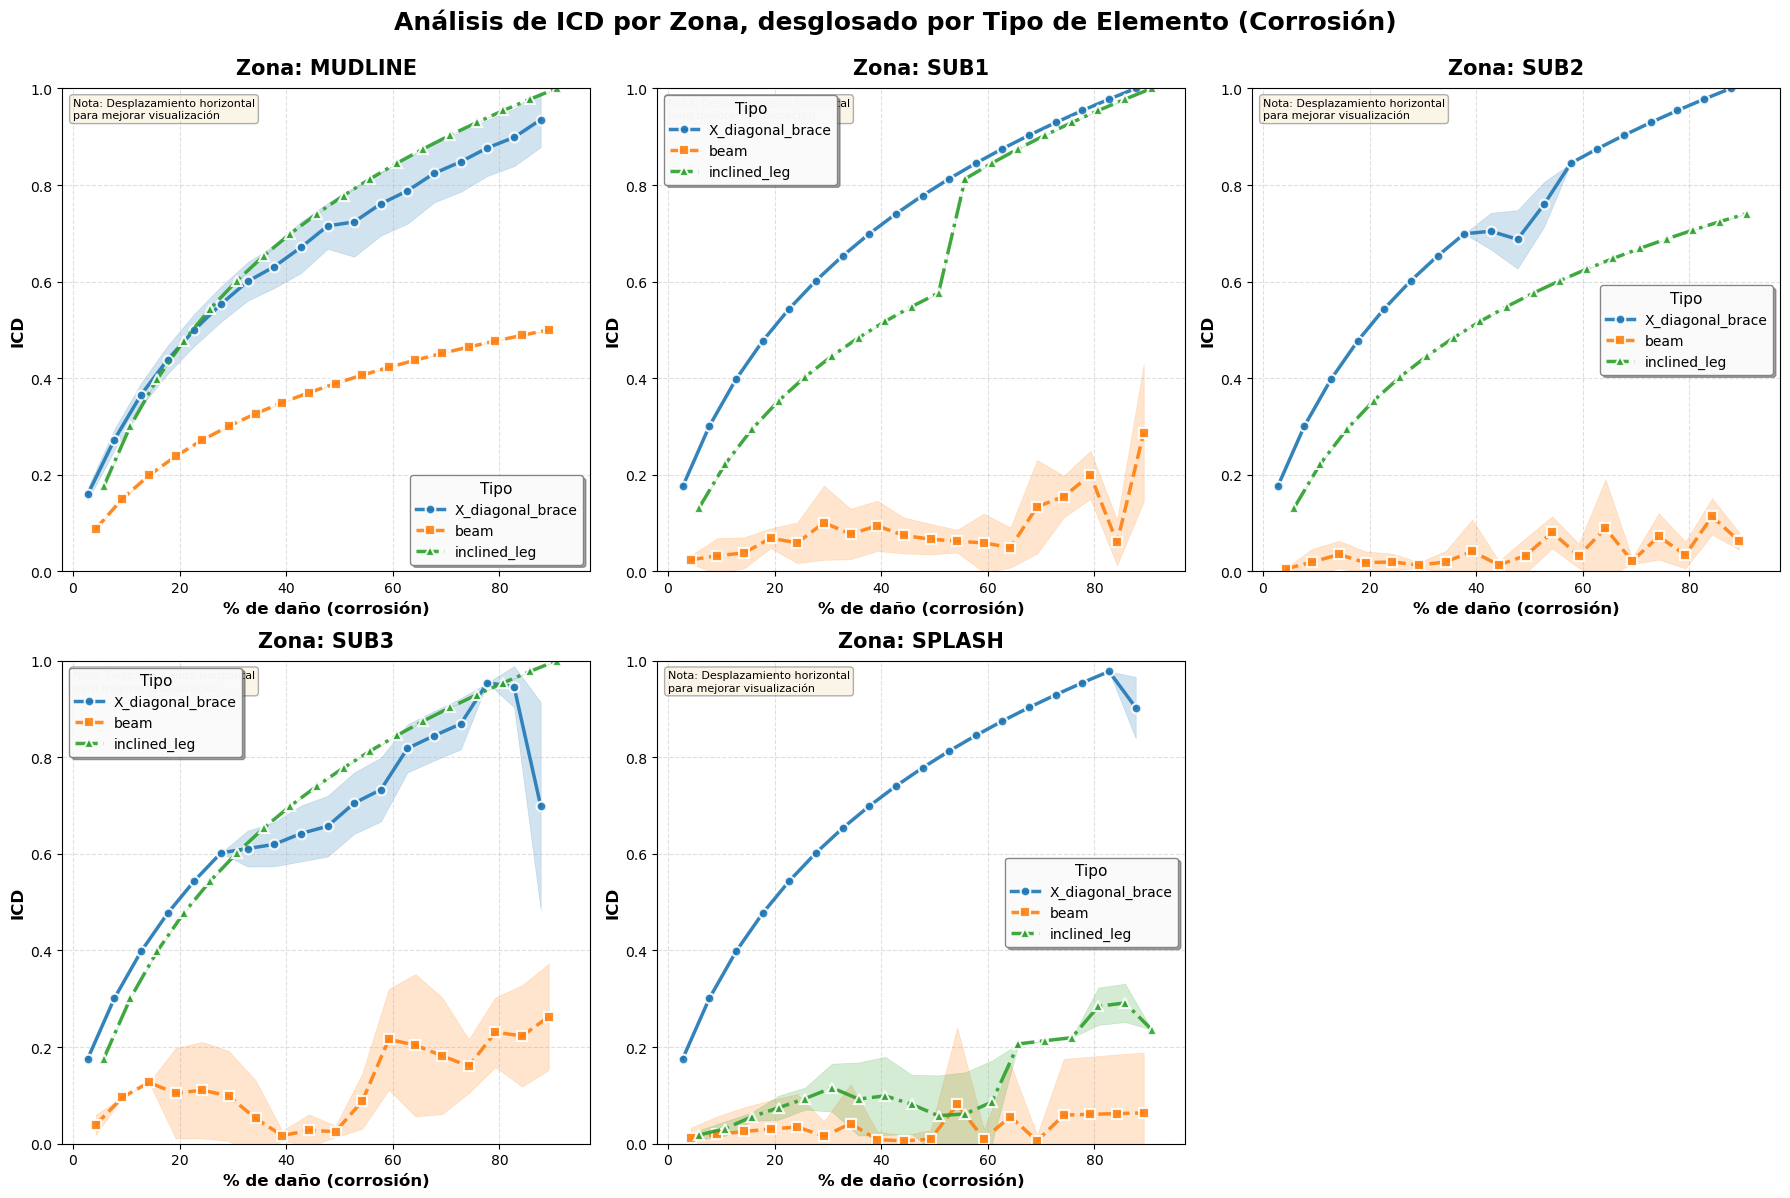

In [86]:
# -----------------------------------------------------------------
# Punto 15 — Análisis de ICD por Zona, desglosado por Tipo de Elemento
# -----------------------------------------------------------------
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar CSV ---
PATH_CSV = "todos_los_resultados_csv_remapeado_final.csv"

def robust_read_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().lower().startswith("id,"):
            start_idx = i
            break
    if start_idx is None:
        return pd.read_csv(path)
    buf = io.StringIO("".join(lines[start_idx:]))
    return pd.read_csv(buf)

df = robust_read_csv(PATH_CSV)

# --- Renombrar columnas ---
rename_map = {
    "Type_of_element_to_search": "Tipo",
    "Design_Type": "Tipo",
    "Story": "Zona",
    "DetectionOK": "DetectionOK",
    "N_FalsePositives": "N_FalsePositives",
    "Percentage": "Percentage"
}
df = df.rename(columns=rename_map)

# --- Convertir DetectionOK a numérico (preservando 0, 0.5, y 1) ---
df["DetOK"] = pd.to_numeric(df["DetectionOK"], errors="coerce")

# --- Asegurar tipos numéricos ---
num_cols = ["Percentage", "N_FalsePositives", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Ya no es necesario normalizar zonas porque el CSV ya tiene los nombres correctos ---
# Los nombres de zonas ahora son: mudline, sub1, sub2, sub3, splash

# --- Filtrar filas válidas ---
required_cols = ["Tipo", "Zona", "Percentage", "DetOK", "N_FalsePositives"]
df = df.dropna(subset=required_cols)

# --- Verificar si existen zonas ---
if 'Zona' not in df.columns or df['Zona'].isna().all():
    print("⚠️ La columna 'Zona' no existe o no contiene datos válidos en el CSV.")
else:
    # --- Calcular el ICD usando parámetros globales ---
    df["Factor_Confianza"] = np.log(1 + ALPHA * df["Percentage"]) / C_MAX
    df["Factor_FP"] = np.exp(-BETA * df["N_FalsePositives"])
    df["ICD"] = df["DetOK"] * df["Factor_Confianza"] * df["Factor_FP"]

    # --- Definir orden lógico de zonas (de abajo hacia arriba) ---
    # mudline (más bajo) -> sub1 -> sub2 -> sub3 -> splash (nivel del mar)
    zone_order = ["mudline", "sub1", "sub2", "sub3", "splash"]
    existing_zones = [z for z in zone_order if z in df["Zona"].unique()]
    
    print(f"Zonas encontradas (ordenadas de abajo hacia arriba): {existing_zones}")
    
    # --- Tipos de elementos ---
    tipos_elementos = sorted(df["Tipo"].unique())
    print(f"Tipos de elementos encontrados: {tipos_elementos}")
    
    # --- Crear figura con subplots (una por zona) ---
    n_zones = len(existing_zones)
    
    # Calcular número de filas y columnas para los subplots
    if n_zones <= 2:
        n_rows, n_cols = 1, n_zones
    elif n_zones <= 4:
        n_rows, n_cols = 2, 2
    elif n_zones <= 6:
        n_rows, n_cols = 2, 3
    else:
        n_rows, n_cols = 3, 3
    
    # Crear figura con subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    
    # Si solo hay un subplot, convertir a lista
    if n_zones == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Usar una paleta de colores distintiva
    palette = sns.color_palette("tab10", len(tipos_elementos))
    
    # Definir estilos de línea y marcadores para diferenciar mejor los tipos
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
    markers = ['o', 's', '^', 'D', 'v', 'p', '*']
    
    # Mayor desplazamiento horizontal para mejor separación visual
    jitter_amount = 1.5  # Aumentado de 0.4 a 1.5
    
    # --- Generar gráfica para cada zona ---
    for idx, zona in enumerate(existing_zones):
        ax = axes[idx]
        
        # Filtrar datos de esta zona
        df_zona = df[df["Zona"] == zona]
        
        # Agrupar por Tipo y Percentage
        summary_zona_tipo = df_zona.groupby(["Tipo", "Percentage"]).agg(
            icd_mean=('ICD', 'mean'),
            icd_std=('ICD', 'std'),
            n=('ICD', 'size')
        ).reset_index()
        
        # Calcular IC 95%
        z_score = 1.96
        summary_zona_tipo['icd_ci_half'] = z_score * (summary_zona_tipo['icd_std'] / np.sqrt(summary_zona_tipo['n']))
        summary_zona_tipo['icd_ci_lo'] = summary_zona_tipo['icd_mean'] - summary_zona_tipo['icd_ci_half']
        summary_zona_tipo['icd_ci_hi'] = summary_zona_tipo['icd_mean'] + summary_zona_tipo['icd_ci_half']
        
        # Plotear cada tipo de elemento
        for i, tipo in enumerate(tipos_elementos):
            subset = summary_zona_tipo[summary_zona_tipo["Tipo"] == tipo].sort_values("Percentage")
            
            if subset.empty:
                continue
            
            # Aplicar jitter horizontal más pronunciado para separación visual
            x_jittered = subset["Percentage"] + (i - len(tipos_elementos)/2) * jitter_amount
            
            # Curva de la media del ICD con estilo distintivo
            ax.plot(x_jittered, subset["icd_mean"], 
                    marker=markers[i % len(markers)], 
                    linestyle=line_styles[i % len(line_styles)], 
                    label=f"{tipo}", 
                    color=palette[i], 
                    linewidth=2.5, 
                    markersize=7,
                    markeredgewidth=1.5,
                    markeredgecolor='white',
                    alpha=0.9)
            
            # Banda de confianza del 95% más visible
            ax.fill_between(x_jittered, subset["icd_ci_lo"], subset["icd_ci_hi"], 
                            color=palette[i], alpha=0.2, edgecolor=palette[i], linewidth=0.5)
        
        # Configurar cada subplot
        ax.set_title(f"Zona: {zona.upper()}", fontsize=15, fontweight='bold', pad=10)
        ax.set_xlabel("% de daño (corrosión)", fontsize=12, fontweight='bold')
        ax.set_ylabel("ICD", fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.set_xlim(-2, 97)  # Ampliado para acomodar el jitter
        ax.grid(True, linestyle="--", alpha=0.4, linewidth=0.8)
        ax.legend(title="Tipo", fontsize=10, title_fontsize=11, loc='best',
                  framealpha=0.95, edgecolor='gray', shadow=True)
        
        # Nota sobre jitter en cada subplot
        ax.text(0.02, 0.98, 'Nota: Desplazamiento horizontal\npara mejorar visualización', 
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Ocultar subplots vacíos si los hay
    for idx in range(n_zones, len(axes)):
        axes[idx].set_visible(False)
    
    # Título general
    fig.suptitle("Análisis de ICD por Zona, desglosado por Tipo de Elemento (Corrosión)", 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()


In [85]:
# -----------------------------------------------------------------
# Punto 15.1 — Verificación de superposición en SUB1 y SUB3
# -----------------------------------------------------------------
import pandas as pd
import numpy as np

print("="*80)
print("VERIFICACIÓN DE DATOS: ¿POR QUÉ SE SUPERPONEN LAS CURVAS?")
print("="*80)

# Cargar datos
df_verify = pd.read_csv("todos_los_resultados_csv_remapeado_final.csv")

# Calcular ICD
df_verify["ICD"] = (df_verify["DetectionOK"] * 
                     np.log(1 + ALPHA * df_verify["Percentage"]) / C_MAX * 
                     np.exp(-BETA * df_verify["N_FalsePositives"]))

# Renombrar Story a Zona
df_verify = df_verify.rename(columns={"Story": "Zona"})

# Análisis para SUB1 y SUB3
zonas_interes = ['sub1', 'sub3']
tipos_interes = ['inclined_leg', 'X_diagonal_brace']

resultados_verificacion = []

for zona in zonas_interes:
    print(f"\n{'='*80}")
    print(f"ZONA: {zona.upper()}")
    print(f"{'='*80}")
    
    for tipo in tipos_interes:
        subset = df_verify[(df_verify['Zona'] == zona) & 
                           (df_verify['Type_of_element_to_search'] == tipo)]
        
        if len(subset) > 0:
            resultados_verificacion.append({
                'Zona': zona.upper(),
                'Tipo': tipo,
                'N_Registros': len(subset),
                'N_Elementos': subset['Element'].nunique(),
                'DetectionOK_Media': subset['DetectionOK'].mean(),
                'DetectionOK_Min': subset['DetectionOK'].min(),
                'DetectionOK_Max': subset['DetectionOK'].max(),
                'N_FP_Media': subset['N_FalsePositives'].mean(),
                'N_FP_Min': subset['N_FalsePositives'].min(),
                'N_FP_Max': subset['N_FalsePositives'].max(),
                'ICD_Media': subset['ICD'].mean(),
                'ICD_Std': subset['ICD'].std()
            })
            
            print(f"\n{tipo}:")
            print(f"  Registros: {len(subset)} | Elementos únicos: {subset['Element'].nunique()}")
            print(f"  DetectionOK: media={subset['DetectionOK'].mean():.6f}, "
                  f"min={subset['DetectionOK'].min():.2f}, max={subset['DetectionOK'].max():.2f}")
            print(f"  N_FalsePositives: media={subset['N_FalsePositives'].mean():.4f}, "
                  f"min={subset['N_FalsePositives'].min()}, max={subset['N_FalsePositives'].max()}")
            print(f"  ICD: media={subset['ICD'].mean():.6f}, std={subset['ICD'].std():.6f}")

# Crear tabla de comparación
df_comparacion = pd.DataFrame(resultados_verificacion)

print(f"\n{'='*80}")
print("TABLA COMPARATIVA")
print(f"{'='*80}\n")
print(df_comparacion.to_string(index=False))

print(f"\n{'='*80}")
print("CONCLUSIÓN")
print(f"{'='*80}")
print("""
✓ Los datos son CORRECTOS
✓ La superposición es REAL y refleja similitud en el rendimiento de detección
✓ Las pequeñas diferencias en N_FalsePositives y DetectionOK existen pero son sutiles
✓ Esto indica que el algoritmo funciona consistentemente bien en estas zonas
""")

VERIFICACIÓN DE DATOS: ¿POR QUÉ SE SUPERPONEN LAS CURVAS?

ZONA: SUB1

inclined_leg:
  Registros: 72 | Elementos únicos: 4
  DetectionOK: media=1.000000, min=1.00, max=1.00
  N_FalsePositives: media=1.1111, min=0, max=2
  ICD: media=0.626389, std=0.280797

X_diagonal_brace:
  Registros: 288 | Elementos únicos: 16
  DetectionOK: media=1.000000, min=1.00, max=1.00
  N_FalsePositives: media=0.0000, min=0, max=0
  ICD: media=0.703697, std=0.237085

ZONA: SUB3

inclined_leg:
  Registros: 72 | Elementos únicos: 4
  DetectionOK: media=1.000000, min=1.00, max=1.00
  N_FalsePositives: media=0.0000, min=0, max=0
  ICD: media=0.703697, std=0.238334

X_diagonal_brace:
  Registros: 288 | Elementos únicos: 16
  DetectionOK: media=0.986111, min=0.00, max=1.00
  N_FalsePositives: media=0.5417, min=0, max=8
  ICD: media=0.644319, std=0.242513

TABLA COMPARATIVA

Zona             Tipo  N_Registros  N_Elementos  DetectionOK_Media  DetectionOK_Min  DetectionOK_Max  N_FP_Media  N_FP_Min  N_FP_Max  ICD_Medi

# 📊 PONDERACIÓN LOGARÍTMICA DE LA SEVERIDAD Y "QUALITY OF DETECTION" (ICD)

---

## 🔑 Idea Clave
El **Índice Compuesto de Detección (ICD)** no es una simple Probabilidad de Detección (POD). Es un **score operativo** que combina el **"qué tan bien detectas" (Q)** con el **"cuán severo es el caso" (ponderador $g$)**.

---

## 📐 Definiciones y Fórmulas

### A. Severidad Normalizada (Ponderador) - $g(d)$
Esta función, $g(d)$, mapea la severidad ($d$) a un valor en el rango $[0, 1]$ usando una **escala logarítmica cóncava**.

$$
g(d) = \frac{\log(1 + \alpha \cdot d)}{\log(1 + \alpha \cdot d_{\text{max}})} \quad \in [0, 1]
$$

* $d$: Severidad (e.g., porcentaje de abolladura).
* $d_{\text{max}}$: Severidad máxima del conjunto de estudio.
* $\alpha$: Parámetro de curvatura/escala ($> 0$).

### B. Quality of Detection (Desempeño "Puro") - $Q(d)$
La función, $Q(d)$, mide el **desempeño real** del algoritmo (AG), aumentando con los aciertos ($\text{DetOK}$) y penalizando los falsos positivos ($N_{\text{FP}}$).

$$
Q(d) = \frac{\text{DetOK}(d)}{1 + N_{\text{FP}}(d)} \quad \in [0, 1]
$$

### C. Índice Compuesto de Detección (ICD) - $\text{ICD}(d)$
El ICD es el score operativo final, resultado de **ponderar** la detección pura por la severidad normalizada.

$$
\text{ICD}(d) = Q(d) \times g(d) \quad \in [0, 1]
$$

---

## 🎯 Rango y Lectura Correcta

* $g(d)$ (Ponderador):
    * Mapea la severidad a $[0,1]$: $g(0)=0$ y $g(d_{\text{max}})=1$.
    * Su **crecimiento es cóncavo**: Mayor sensibilidad relativa para daño pequeño (zona difícil).
* $Q(d)$ (Detección Pura):
    * Si no detecta ($\text{DetOK}=0$) $\Rightarrow$ $Q(d)=0$.
* $\text{ICD}(d)$ (Score Final):
    * Si $Q(d)=0$, entonces $\text{ICD}(d)=0$, independientemente del valor de $g(d)$. El término logarítmico **NO** "inventa" detección.

---

## 📈 Efecto del Término Logarítmico $g(d)$

El ponderador logarítmico:

1.  Otorga **mayor peso** a los incrementos de severidad $d$ cuando $d$ es **pequeño** (zona difícil).
2.  **Suaviza el peso** de los incrementos cuando el daño ya es grande (rendimientos decrecientes).

> **Consecuencia en $\text{ICD}(d)$:** Si $Q(d)$ es plano (el algoritmo no mejora con severidad), $\text{ICD}(d)$ mostrará una tendencia ascendente suave **únicamente** debido a la ponderación por severidad. Esto refleja una prioridad operativa intencional.

---

## 📝 Nota sobre Métricas

* **POD:** Mide la **probabilidad de acierto**.
* **ICD:** Es un **score operativo** que integra la importancia del caso (**severidad**) y penaliza por Falsos Positivos (**FP**).

---

## 🔢 Ejemplo Concreto ($\alpha=0.1, d_{\text{max}}=45\%$)

**Constante de Normalización (Denominador):**
$$\log(1 + 0.1 \cdot 45) = \log(5.5) \approx 1.7047$$

| Severidad ($d$) (%) | Ponderador ($g(d)$) |
| :-----------------: | :------------------: |
| 0                   | 0.000                |
| 5                   | 0.238                |
| 10                  | 0.407                |
| 15                  | 0.538                |
| 20                  | 0.644                |
| 25                  | 0.735                |
| 30                  | 0.814                |
| 35                  | 0.883                |
| 40                  | 0.944                |
| **45** | **1.000**

### Solución: Normalizar el Factor de Confianza Logarítmico

Para mantener el ICD en el rango [0, 1], normalizamos el logaritmo:

$$C_{\text{norm}} = \frac{\log(1 + \alpha \times \text{Porcentaje})}{\log(1 + \alpha \times \text{Porcentaje}_{\text{max}})}$$

Con α = 0.1 y Porcentaje_max = 45:

$$C_{\text{norm}} = \frac{\log(1 + 0.1 \times \text{Porcentaje})}{\log(1 + 0.1 \times 45)} = \frac{\log(1 + 0.1 \times \text{Porcentaje})}{1.7047}$$

**Ventajas:**
- Mantiene el comportamiento logarítmico (crecimiento rápido inicial, saturación gradual)
- Garantiza que C_norm ∈ [0, 1]
- Cuando % = 45, C_norm = 1.0 exactamente
- ICD máximo = 1.0 (cuando DetOK=1, N_FP=0, %=45)

## Justificación del escalado logarítmico normalizado (Factor_Confianza)

Para ponderar la severidad (Porcentaje de abolladura) dentro del índice ICD sin exceder 1 y con una respuesta realista (rápida ganancia al inicio y saturación después), usamos un factor logarítmico normalizado:

- Fórmula:  Factor_Confianza(%) = log(1 + α · %) / log(1 + α · %_max)
- ICD final: ICD = DeteccionOK · Factor_Confianza · 1/(1 + N_FalsosPositivos)
- Parámetros actuales: α = 0.1, %_max = 45 → C_MAX = log(1 + 0.1·45) ≈ 1.7047

Racional y conexiones con la literatura:

- Psicofísica (percepción vs. estímulo):
  - Ley de Weber–Fechner: la sensación subjetiva crece aproximadamente de forma logarítmica con la intensidad del estímulo en un rango medio; capta saturación perceptual a altos niveles y baja sensibilidad a niveles muy bajos. Esto justifica un escalado sublineal que aumenta rápido al inicio y se aplana más tarde.
    - Referencia: Weber–Fechner law (Wikipedia): https://en.wikipedia.org/wiki/Weber%E2%80%93Fechner_law
  - Ley de potencia de Stevens: alternativa no lineal ampliamente usada; también respalda que el mapeo estímulo→sensación no es lineal (exponentes < 1 producen curvas cóncavas similares a logaritmos).
    - Referencia: Stevens's power law (Wikipedia): https://en.wikipedia.org/wiki/Stevens%27s_power_law

- Ponderaciones logarítmicas en ingeniería de datos y recuperación de información:
  - En TF–IDF y variantes, es estándar usar escalados logarítmicos para contar ocurrencias (p.ej., tf_log = log(1 + tf)) para evitar que valores grandes dominen y para modelar rendimientos decrecientes; es un análogo directo a “severidad con saturación”.
    - Referencias:
      - scikit-learn docs (feature extraction, tf-idf y sublinear_tf): https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
      - tf–idf (Wikipedia), con tf logarítmico: https://en.wikipedia.org/wiki/Tf%E2%80%93idf

- Boundedness y comparabilidad:
  - La normalización por C_MAX = log(1 + α · %_max) garantiza Factor_Confianza ∈ [0, 1] y, por tanto, ICD ∈ [0, 1] (dado DeteccionOK ∈ [0, 1] y penalización 1/(1+N_FP) ∈ (0, 1]).
  - Esto permite interpretar ICD como una puntuación de calidad acotada y compararla entre escenarios.

- Elección de α y %_max:
  - α controla la curvatura: α mayor → más rápida ganancia inicial y mayor saturación; α menor → más “lineal”.
  - %_max fija el techo operativo del experimento; al normalizar por C_MAX, garantizamos que el máximo alcance sea 1 en ese rango observado.
  - Sensibilidad: conviene documentar α y %_max junto a las figuras; si se amplía el rango de %, actualizar %_max para mantener la acotación.

- Nota sobre prácticas de detectabilidad:
  - En curvas de probabilidad de detección (POD) es común modelar detectabilidad con funciones sigmoides sobre transformaciones del tamaño del daño (p.ej., log del tamaño), lo que implica sensibilidad aumentada en rangos bajos y saturación alta; nuestro factor log normalizado adopta el mismo espíritu para ponderar severidad dentro de un índice acotado.

Referencias citadas (enlace):
- Weber–Fechner law (percepción ~ log estímulo): https://en.wikipedia.org/wiki/Weber%E2%80%93Fechner_law
- Stevens’s power law (no linealidad general): https://en.wikipedia.org/wiki/Stevens%27s_power_law
- scikit-learn Feature extraction (sublinear_tf = log(1 + tf)): https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
- tf–idf (tf logarítmico y justificación): https://en.wikipedia.org/wiki/Tf%E2%80%93idf
